In [1]:
# LE VARIABILI GLOBALI CHE DEVONO ESSERE USATE:
# NOME DELLE CARTELLE DA USARE NELL'ORGANIZZAZIONE DEL DATASET:
import os
A_FOLDER= 'Longitudinal_Studies'
S_FOLDER= 'Super_Resolution'
P_FOLDER = 'Mosaicing'

TEST_FOLDER= 'Test'
REFERENCE_FOLDER= 'Reference'
IMAGE_FOLDER = 'ImgRes'
NUM_WORKERS =  0 # os.cpu_count() # to define the num of subprocesses to use for dataloader
FIXED = '_1'
MOVING = '_2'
LOWEDGE_BOX = 1.5/9.0
HIGHEDGE_BOX = 7.5/9.0
BATCH_SIZE = 1
N_NEURONS = 100
ORIGINAL_SHAPE = (2912, 2912)




In [2]:
#NOTE other cuseful constants
from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime

this_file_path = Path.cwd()

RESULT_PATH = Path.cwd().parent / 'Results'
elastix_saving_folder = RESULT_PATH / 'ITK-Elastix'
result_image_folder = this_file_path.parent /'Results' /'ImgRes'
CONTROL_POINTS_FOLDER= this_file_path.parent / 'Modules' / 'dataset' / 'FIRE' / 'Ground Truth'
print(f'the path is: {CONTROL_POINTS_FOLDER}\nthe path exist: {os.path.exists(CONTROL_POINTS_FOLDER)}')

# useful for date/time infos: 
now = datetime.now()
current_time = now.strftime("%Y%m%d-%H%M%S"); print(f"Current Time = {current_time}")


the path is: c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\dataset\FIRE\Ground Truth
the path exist: True
Current Time = 20260130-130024


c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from timeit import default_timer as timer 
import time
from contextlib import contextmanager
from functools import wraps

import torch
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

# creation of a time tracker for functions as decorator:
def timeit(func):
    '''it get the time taken by a function to execute, to get the value
    of time from the function results, use it as follows: 
    @timeit
    def my_function(...):
        ...
        return result

    result, time_taken = my_function(...)'''
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        time_taken = end - start
        # NOTE use logging to get the time taken info
        return result, time_taken
    return wrapper

#creation of a context manager to get the time taken by a code block:
@contextmanager
def block_time():
    '''Context manager to measure the time taken by a code block.
    Usage: 
    with block_time() as t:
        # code block to measure
        ...
    time_taken = t[0]
    '''
    start = time.perf_counter()
    t = [None]
    yield t
    t[0] = time.perf_counter() - start
    
    #NOTE use it as a log print(f"Block executed in {time_taken:.4f} seconds")

def get_data_time()->str:
    '''Get the current date and time as a formatted string specifically for file naming.'''
    now = datetime.now()
    current_time = now.strftime("%Y%m%d-%H%M%S")
    return current_time

In [4]:
from time import sleep
@timeit
def funzione_attesa(t: float,
    )-> float:
    '''
    wait funct to show exemple of timeit and block_time usage
    '''
    with block_time() as bt:
        print(f'waiting for {t} seconds...')
    time_for_first_block = bt[0]
    time.sleep(t)
    print(f'waiting for {t*2} seconds...')

    return time_for_first_block

first_block, execution_time = funzione_attesa(t=2.0)

print(f'the total time of execution is {execution_time:.4f} seconds, the first block took {first_block:.4f} seconds' )

waiting for 2.0 seconds...
waiting for 4.0 seconds...
the total time of execution is 2.0009 seconds, the first block took 0.0001 seconds


# Download the data
url = https://projects.ics.forth.gr/cvrl/fire/FIRE.7z
path_to_zip_file = ''

In [5]:
import os
from pathlib import Path

import requests
from rich.console import Console
from typing import Iterator
from contextlib import contextmanager

url_fire_dataset = 'https://projects.ics.forth.gr/cvrl/fire/FIRE.7z'

#zip_request = requests.get(url_fire_dataset)

@contextmanager
def loading(
    message: str,
) -> Iterator[None]:
    """
    Implement loading animation.

    Parameters
    ----------
    message : str
        The text to print during the animation.

    Returns
    -------
    None

    """
    console = Console()
    try:
        with console.status(f"[bold green]{message}..."):
            yield
    finally:
        console.log(f"[bold green]{message}... Done")


In [6]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning dimension of itscontents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
      in the format:
        for dirpath, dirnames, filenames in os.walk(dir_path):
          print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
 
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
 
    

In [7]:
from pathlib import Path

try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    help_function_path = Path.cwd().parent /'Modules' / "helper_functions.py"
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves


In [8]:
import py7zip
import py7zip.py7zip
import os

fire_path = Path.cwd().parent / 'Modules' / 'dataset'
zip_path = fire_path / 'FIRE.7z'
zip_manager = py7zip.py7zip.Py7zip()
if not  zip_path.exists():
    os.makedirs(fire_path, exist_ok=True)
    with loading('Downloading FIRE dataset'):
        with open(zip_path, 'wb') as f:
            zip_request = requests.get(url_fire_dataset)
            f.write(zip_request.content)  
        if not any(Path(fire_path / 'FIRE').iterdir()): # if there are no dir in ?Path.cwd().parent / 'Dataset' /' FIRE'? dir it will be extracted
            destination = fire_path # FIXME to be changed to Path.cwd().parent / 'Dataset' /' FIRE'
            source = zip_path
            with loading('Decompressing FIRE dataset'):
                zip_manager.decompress(src = zip_path, dest = fire_path)
else:
    print('the dataset folder already exists')



the dataset folder already exists


In [9]:
import os
import py7zr
import requests
import zipfile
from pathlib import Path


def get_dataset(
        dataset_url: str,
        destination_path: Path,
        dataset_name: str = '',
        remove_zip: bool = False
) -> None:
    """
    Download a dataset from a given url and decompress it in a given destination path.

    Parameters
    ----------
    dataset_url : str
        The url of the dataset to download.
    destination_path: Path
        The path where the dataset will be decompressed.
    dataset_name : str, optional
        The name of the dataset file to download.
    remove_zip : bool, optional
        Whether to remove the zip file after decompression.
    """
    if dataset_name == '':
        dataset_name = Path(dataset_url).name

    # Create the destination folder if it does not exist
    if destination_path.exists():
        print(f'The {destination_path} folder already exists')
    else:
        os.makedirs(destination_path, exist_ok=True)

    # Control if the dataset_name is present in the folders list of destination_path
    dataset_file = destination_path / dataset_name

    for _, folders, _ in os.walk(destination_path):
        for fold in folders:
            if dataset_name.upper() == fold.upper():
                print(f'[INFO] The {dataset_name} dataset is already extracted in the {destination_path} folder\nNo need to extract it again')
                return None

    # Download and save the dataset from the given url
    if dataset_file.exists():
        print(f'[INFO] {dataset_name} already exists, no need to download it again')
    else:
        zip_request = requests.get(dataset_url)
        with open(dataset_file, 'wb') as f:
            f.write(zip_request.content)

    # Decompress the dataset if not already done
    if dataset_file.suffix == '.7z':
        with py7zr.SevenZipFile(dataset_file, mode='r') as archive:
            archive.extractall(path=destination_path)
    elif dataset_file.suffix == '.zip':
        with zipfile.ZipFile(dataset_file, 'r') as archive:
            archive.extractall(path=destination_path)
    else:
        print(f'[ERROR] Unsupported archive format: {dataset_file.suffix}')
        return None

    if remove_zip:
        os.remove(dataset_file)

    print(f'[INFO] {dataset_name} has been successfully downloaded and extracted to {destination_path}')
    return None

In [10]:
#get_dataset(dataset_url = url_fire_dataset, destination_path = fire_path, dataset_zip = 'FIRE.7z', remove_zip = True) # FIXME destination_path to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images'
fire_zip = fire_path / 'FIRE.7z'

#get_dataset(dataset_url='https://projects.ics.forth.gr/cvrl/fire/FIRE.7z',destination_path=fire_path,remove_zip=False)

## Categorization Test images - Reference images

In [11]:
import os
import shutil

def organize_folder(parent_folder : Path, # the path folder to organize
                    categories : list[str], # name of the folders
                    folder_names: list[str] = []): # the categories of daughter folders
    # aggiungi un file.suffix per il tipo di file da organizzare e spostare nella cartella
    '''given a certain parent dir it reorganize the files respecting the categories:

    assure to give the respective order between the folder name and the categories if given
    EXAMPLE: 
        folder_names = ['truth', 'fake']
        categories ['_1', '_2']
        if _1 corresponds to truth folder
    '''
    if not len(categories):
        print('[ERROR] the categories must be given')
        return 
    
    
    # get the list of files in parent folder
    files = [f for f in parent_folder.glob('*') if f.is_file()]
    if not len(files):
        print(f'[ERROR] there are no files in {parent_folder}')
    # control if categories are indentifiable
    absent_cat =[]
    for cat in categories:
        cat_not_in = False
        for file in files:
            if cat in file.name:
                cat_not_in = True
                break
        if not cat_not_in :
            absent_cat.append(cat)
    for cat in set(absent_cat):
        print(f'[ERROR] the category {cat} is not identifiable in the files')
            
        
    # control if folder names is given:
    if not len(folder_names):
        folder_names = categories
    
    for daughter_folder in folder_names:
        # create the folder if it does not exist
        daughter_folder_path = parent_folder / daughter_folder
        
        if not daughter_folder_path.is_dir():
            os.makedirs(daughter_folder_path, exist_ok=True)
        
        #then move the file if the type of category is in
    path_cat_dict = {k.upper():v for k , v in zip(categories, folder_names)}

    for file in files:
        for cat in categories:
            if file.name.__contains__(cat.upper()):
                new_folder = parent_folder / path_cat_dict[cat.upper()] / file.name #parent_folder / path_cat_dict[cat]
                shutil.move(src=str(file), dst=str(new_folder))
                break

   
                


In [12]:
image_type = ['Reference','Test']
categories = ['_1', '_2']
fire_images_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images'
if not Path(fire_images_path/ 'Reference' ).exists():
    organize_folder(parent_folder=fire_images_path, categories=categories, folder_names=image_type)

image_type = ['Longitudinal_Studies', 'Mosaicing', 'Super_Resolution']
categories = ['A', 'P', 'S']
reference_images_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' / 'Reference' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images' /' Reference'
if not Path(fire_images_path/ 'Reference' / 'Mosaicing').exists():
    organize_folder(parent_folder=reference_images_path, categories=categories, folder_names=image_type)
test_images_path =Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' / 'Test' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images' / 'Test'
if not Path(fire_images_path/ 'Test' / 'Mosaicing').exists():
    organize_folder(parent_folder=test_images_path, categories=categories, folder_names=image_type)


In [13]:
for n,i in enumerate(Path.cwd().parents):
    print(f'Path.cwd()[{n}] stands for {i} ')
print(f'{Path.cwd()}')

Path.cwd()[0] stands for c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder 
Path.cwd()[1] stands for c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE 
Path.cwd()[2] stands for c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER 
Path.cwd()[3] stands for c:\Users\gioco\Desktop 
Path.cwd()[4] stands for c:\Users\gioco 
Path.cwd()[5] stands for c:\Users 
Path.cwd()[6] stands for c:\ 
c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Main_Code


In [14]:
reference_files = list(reference_images_path.rglob('**/*.jpg'))
test_files = list(test_images_path.rglob('**/*.jpg'))
len(reference_files)== len(test_files)
reference_files[1], test_files[1]

(WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A02_1.jpg'),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Test/Longitudinal_Studies/A02_2.jpg'))

## Creation of the DATASET and DATALOADER

In [15]:
# generate a file path as sample to test all the sequent code:
example_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' 
list_images = list(example_path.glob('*/*/*.jpg'))
example_image_path = list_images[0]
example_image_path

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A01_1.jpg')

In [16]:
def get_dirs_of(file_path : Path,
                 
                )->list[str]:
    '''
    given a certain path it get all the dir as a list of str to get this image
    in the format of a list as:

    [test/reference, deformation_type, file_name]

    ['Reference', 'Longitudinal_Studies', 'A01_1.jpg']
    '''
    if not file_path.is_file():
        image_type, image_deformation = file_path.parts[-2:]
        return [image_type, image_deformation]
        
    image_type, image_deformation, file_name =  file_path.parts[-3:]
    return [image_type, image_deformation, file_name]
get_dirs_of(example_image_path)


['Reference', 'Longitudinal_Studies', 'A01_1.jpg']

### SIMPLE DATALOADER

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from typing import Tuple, List
import random
import os
from pathlib import Path

class SimpleImRegDataSet(Dataset):
    '''A simple dataloader to load image pairs from a dataset in a gven folder structure'''
    def __init__(self, 
                 dataset_folder_path: Path,
                 reference_folder_name: str | Path,
                 test_folder_name: str | Path,
                 transforms=None) -> None:
        
        self.dataset_folder_path = dataset_folder_path
        self.reference_folder_name = reference_folder_name
        self.test_folder_name = test_folder_name
        self.transforms = transforms
        self.test_images = list(self.dataset_folder_path.glob(f'Images/{self.test_folder_name}/*/*'))
        self.reference_images = list(self.dataset_folder_path.glob(f'Images/{self.reference_folder_name}/*/*'))

    def __len__(self) -> int:
        tot_images = len(self.test_images) + len(self.reference_images)
        return tot_images

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        if index not in range(0, len(self.test_images)):
            print(f'[WARNING] - unable to get the {index} image, another one casually get from the dirs')
            index = random.randint(0, len(self.test_images) - 1)
        
        test_image = Image.open(self.test_images[index])
        reference_image = Image.open(self.reference_images[index])
        test_image_name = self.test_images[index].stem
        reference_image_name = self.reference_images[index].stem
        
        if self.transforms:
            test_image = self.transforms(test_image)
            reference_image = self.transforms(reference_image)
        
        return test_image, reference_image, test_image_name, reference_image_name
    
fire_dataset_path= Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' 
transform_tensor = transforms.Compose([transforms.ToTensor()])
dataset = SimpleImRegDataSet(dataset_folder_path=fire_dataset_path, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)

# Creare il dataloader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)



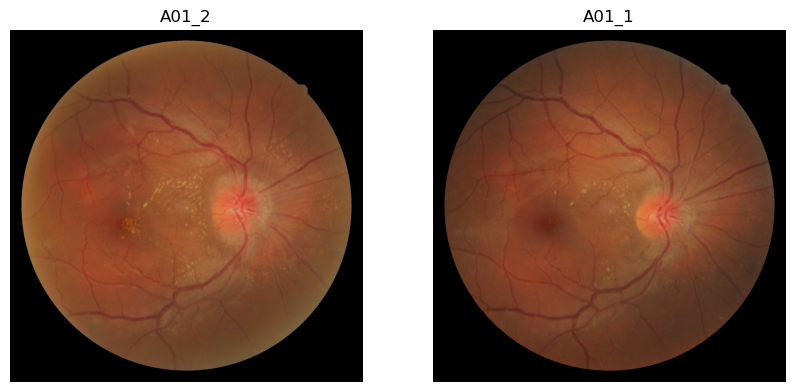

In [18]:
import matplotlib.pyplot as plt
import numpy as np
iter_dataloader = iter(dataloader)
first_batch = next(iter_dataloader)
second_batch = next(iter_dataloader)
third_batch = next(iter_dataloader)
img_ref, img_test, test_image_name, reference_image_name = first_batch



def show_image(test_image : torch.Tensor,
               reference_image: torch.Tensor,
               test_image_name: str = '',
               reference_image_name: str = ''
               )->None:
    #reference_image, test_image, test_image_name, reference_image_name = batch in case to use the dataloader itself
    reference_image_name, test_image_name = str(reference_image_name[0]), str(test_image_name[0])
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(test_image.squeeze().permute(1,2,0).numpy())
    ax[0].set_title(f'{test_image_name}')
    ax[0].axis('off')
    ax[1].imshow(reference_image.squeeze().permute(1,2,0).numpy())
    ax[1].set_title(f'{reference_image_name}')
    ax[1].axis('off')
    plt.show()

show_image(test_image=img_test, reference_image=img_ref, test_image_name=test_image_name, reference_image_name=reference_image_name)

    

### CUSTOM DATALOADER

In [19]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from typing import Tuple, Dict, List
import torch
import random
import os
from pathlib import Path

class ImageRegistrationCustom(Dataset):
    def __init__(self,
                dataset_folder_path: Path, # the path of FIRE dataset: Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE'
                transform=None, 
                target_transform=None)->None:
        self.dataset_path = dataset_folder_path
        path_to_image_types = dataset_folder_path / 'Images' 
        path_to_deformation_types = dataset_folder_path /  'Images' / 'Test' 
        self.reference_images_paths = list(dataset_folder_path.glob('Images/Reference/*/*.jpg'))
        self.test_images_paths = list(dataset_folder_path.glob('Images/Test/*/*.jpg'))
        self.transform = transform # da trasformare le singole immagini? 
        self.target_transform = target_transform
        self.image_types = [d.name for d in path_to_image_types.iterdir() if d.is_dir()]
        self.deformation_types = [d.name  for d in path_to_deformation_types.iterdir() if d.is_dir()]

    # costruisci un dict  per abbreviare long... super res e mosaicing in A, S, P ... ?
    def load_image(self, 
                   index : str | int = 'random', # valuta la possibilità di mettere il random in una funzione a parte
                   deformation: str= '') ->Image.Image: # given an index it get an image
        ''' 
        depending the type there are different possibilities
        depending which type f deformation to visualize
        ****aggiungi la possibilità di usare una trasformazione su un'immagine di test 
        '''
        images = list(self.dataset_path.glob('*/*/*/*'))
        
        if deformation == '':
            images = list(self.dataset_path.glob('*/*/*/*'))
        else:
            if deformation not in self.deformation_types:
                print(f'to see possibile selection use the method .deformation_types')
                raise ValueError(f"Deformation type {deformation} not found in the dataset")
            else:
                images = list(self.dataset_path.glob(f'*/*/*/{deformation}/*'))
        
        if index.lower() == 'random' or not isinstance(index, int):
            idx = random.randint(0, len(images)-1)
        elif isinstance(index, int):
            idx=index
            if index not in range(0, len(images)):
                print(f'[WARNING] - unable to get the {index} image, another one casually get from the dirs')
                idx = random.randint(0, len(images) - 1)
                images = list(self.dataset_path.glob('*/*/*/*')) 
        
        return Image.open(images[idx])      # aggiusta in una tupla 
        

    def __len__(self,
                info : bool = True):
        '''show the distribution of sample in the dataset path
        then the number of total files in the deepest folder'''
        if info:
            for dirpath, dirnames, filenames in os.walk(self.dataset_path):
                print(f"[INFO] - There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
        return len(list(self.dataset_path.glob('*/*/*/*')))
    
    def get_coupled_imgs(self,
                    index: bool|int = False,
                    deformation_choice : str = '' 
                    ) -> Tuple[torch.Tensor, torch.Tensor, str]:
        '''get the image pairs from the list of avaiable '''
        if deformation_choice == '' or deformation_choice not in self.deformation_types:
            test_images = list(self.dataset_path.glob('*/Test/*/*'))
            reference_images = list(self.dataset_path.glob('*/Reference/*/*'))
            print('[WARNING] - not a valid choice of deformation, the entire dataset is used as a batch') 
        else: 
            test_images = list(self.dataset_path.glob(f'*/*/Test/{deformation_choice}/*'))
            reference_images = list(self.dataset_path.glob(f'Images/Reference/{deformation_choice}/*.jpg'))
        if not index or index not in range(0, len(test_images)):
            index = random.randint(0, len(test_images)-1)
            
        test_image = test_images[index]
        reference_image = reference_images[index]
        test_reference,deformation, filename = get_dirs_of(test_image)
        print(f'the selected/chosen image is {filename}, from {deformation} folder of {test_reference}')
        if self.transform:
            reference_image = self.transform(Image.open(reference_image))  
        if self.target_transform:
            test_image = self.target_transform(Image.open(test_image))
        return test_image, reference_image, deformation

    def __getitem__(self, 
                    index : bool|int = False,
                    deformation_choice: str = ''):
        ''' get the images couple of reference/test as tensor tuple'''
        test_image, reference_image, _ = self.get_coupled_imgs(index=index, deformation_choice=deformation_choice)
        if self.transform:
            test_image = self.transform(test_image)
        if self.target_transform:
            reference_image = self.target_transform(reference_image)
        return test_image, reference_image 
            
        

In [20]:
fire_dataset_path = Path.cwd().parent / 'Modules' /'dataset'/'FIRE'

imreg_dataset = ImageRegistrationCustom(dataset_folder_path=fire_dataset_path)
img= imreg_dataset.load_image(deformation='', index='random')

test_img, reference_img, deformation = imreg_dataset.get_coupled_imgs()

print(f'the shape of the image *test_img* open with Image.open(Path): {np.asarray(Image.open(test_img)).shape}, type {type(Image.open(test_img))}\n just befor numpy conversion')
print(f'the shape of the image *img_test* open with the DAtaloader as a tensor: {img_test.shape}, type {type(img_test)}')

[WARNING] - not a valid choice of deformation, the entire dataset is used as a batch
the selected/chosen image is P09_2.jpg, from Mosaicing folder of Test
the shape of the image *test_img* open with Image.open(Path): (2912, 2912, 3), type <class 'PIL.JpegImagePlugin.JpegImageFile'>
 just befor numpy conversion
the shape of the image *img_test* open with the DAtaloader as a tensor: torch.Size([1, 3, 2912, 2912]), type <class 'torch.Tensor'>


### DATALOADER + PYRAMID 
get the dataloader from simply dataloader and add pyramid transformation after transforms...

## Preprocess the image from the dataloader for the nn

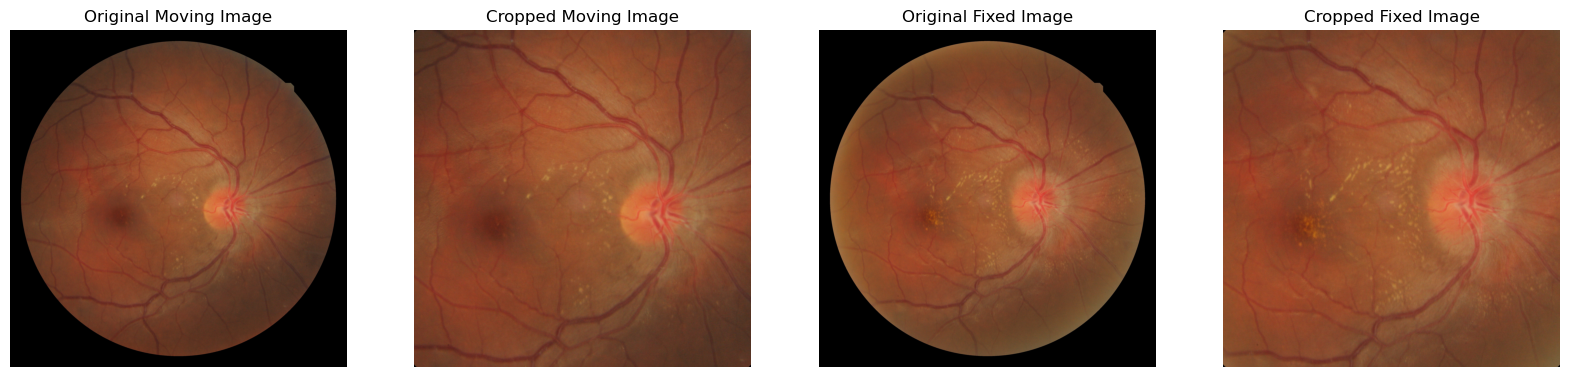

In [21]:
def crop_images(moving_image : Path | torch.Tensor,
                fixed_image : Path | torch.Tensor,
                show_images : bool = False
                )-> Tuple[torch.Tensor, torch.Tensor]:
    '''
    given the images it crop to the desired size 
    if requested the images are shown as confront between the original and the cropped
    
    Parameters:
    moving_image : Path | torch.Tensor
        the image to crop, it can be a path or a tensor given by the dataloader
    fixed_image : Path | torch.Tensor
        the image to crop, it can be a path or a tensor given by the dataloader 
    show_images : bool
        whether to show the images or not
        
    Returns:
        Tuple[torch.Tensor, torch.Tensor]: the cropped images
        
    '''

    #open the images depending on the type
    if isinstance(moving_image, Path):
        if not moving_image.exists():
            raise FileNotFoundError(f'{moving_image} not found')
        else:
            move_image = np.asarray(Image.open(moving_image))
    if isinstance(fixed_image, Path):
        if not fixed_image.exists():
            raise FileNotFoundError(f'{fixed_image} not found')
        else:
            fix_image = np.asarray(Image.open(fixed_image))
    
    if isinstance(moving_image, torch.Tensor):
        move_image = moving_image.squeeze().permute(1,2,0).numpy()
    if isinstance(fixed_image, torch.Tensor):
        fix_image = fixed_image.squeeze().permute(1,2,0).numpy()
    
    cropped_moving_image = move_image[int(move_image.shape[0]*LOWEDGE_BOX):int(move_image.shape[0]*HIGHEDGE_BOX), int(LOWEDGE_BOX*move_image.shape[1]):int(HIGHEDGE_BOX*move_image.shape[1]), :]
    cropped_fixed_image = fix_image[int(LOWEDGE_BOX*fix_image.shape[0]):int(fix_image.shape[0]*HIGHEDGE_BOX), int(LOWEDGE_BOX*fix_image.shape[1]):int(HIGHEDGE_BOX*fix_image.shape[1]), :]


    if show_images:
        # show the images
        fig, ax = plt.subplots(1, 4, figsize=(20, 5))
        ax[0].imshow(move_image)
        ax[0].set_title('Original Moving Image')
        ax[0].axis('off')
        ax[1].imshow(cropped_moving_image)
        ax[1].set_title('Cropped Moving Image')
        ax[1].axis('off')
        ax[2].imshow(fix_image)
        ax[2].set_title('Original Fixed Image')
        ax[2].axis('off')
        ax[3].imshow(cropped_fixed_image)
        ax[3].set_title('Cropped Fixed Image')
        ax[3].axis('off')
        plt.show()
    batched_moving = torch.from_numpy(cropped_moving_image).permute(2,0,1).unsqueeze(0)
    batched_fixed = torch.from_numpy(cropped_fixed_image).permute(2,0,1).unsqueeze(0)
    return batched_moving, batched_fixed

moved_image,fixed_image = crop_images(moving_image=img_ref, fixed_image=img_test, show_images=True)
    


In [22]:
img_ref.shape

torch.Size([1, 3, 2912, 2912])

In [23]:
# given the two tensor with shape of [1, 3, 1941, 1941]
# get the pyramid of images from skimage.transform.pyramid_gaussian
from skimage.transform import pyramid_gaussian
from skimage.filters import gaussian
def coupled_gaussian_pyramid(fixed_image : np.float32 | torch.Tensor,
                             moving_image : np.float32 | torch.Tensor,
                             downscale : float = 2.0,
                             )-> (list[np.float32], list[np.float32], int):
    '''
    it takes two images to performa gaussian filter in 6 progressive steps
    Parameter
    ---------
    fixed_image : np.float32
      the fixed image

    moving_image : np.float32
      the moving image

    downscale : float
      the downscale factor to decide the factor of downsampling in each subsequent step

    Returns
    -------
    (list[np.float32], list[np.float32])
      the gaussian pyramid of the two images
    nChannel : int
      the number of channels of the image

    '''   
    if np.ndim(fixed_image) != np.ndim(moving_image) or type(fixed_image) != type(moving_image):
      raise ValueError("the two images must have the same type and dimension")
    else:
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.squeeze().permute(1,2,0).numpy()
            moving_image = moving_image.squeeze().permute(1,2,0).numpy()
        if np.ndim(fixed_image) == 3:
            nChannel=fixed_image.shape[2]
            pyramid_fixed = tuple(pyramid_gaussian(gaussian(fixed_image, sigma=1, channel_axis=-1), downscale=downscale, channel_axis=-1))
            pyramid_moving = tuple(pyramid_gaussian(gaussian(moving_image, sigma=1, channel_axis=-1), downscale=downscale, channel_axis=-1))
        elif np.ndim(fixed_image) == 2:
            nChannel=1
            pyramid_fixed = tuple(pyramid_gaussian(gaussian(fixed_image, sigma=1, channel_axis=None), downscale=downscale))
            pyramid_moving = tuple(pyramid_gaussian(gaussian(moving_image, sigma=1, channel_axis=None), downscale=downscale))
        else:
            print(f"Unknown rank for an image: {np.ndim(fixed_image)}")

    return (pyramid_fixed, pyramid_moving, nChannel)
pyramid_ref, pyramid_mov, nChannel = coupled_gaussian_pyramid(fixed_image=fixed_image, moving_image=moved_image, downscale=2.0)


## CREATE THE NN 

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.color import rgb2gray
from torch.autograd import Function
import cv2 
import numpy as np
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        # affine transform basis matrices

        self.B = torch.zeros(6,3,3).to(device)
        self.B[0,0,2] = 1.0
        self.B[1,1,2] = 1.0
        self.B[2,0,1] = 1.0 
        self.B[3,1,0] = 1.0 
        self.B[4,0,0], self.B[4,1,1] = 1.0, -1.0
        self.B[5,1,1], self.B[5,2,2] = -1.0, 1.0

        #inizializzatione  parametri
        self.v1 = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)
        self.vL = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)

    def forward(self, s):
        C = torch.sum(self.B*self.vL,0)
        if s==0: # caso in cui ci si trovi nel primo livello
            C += torch.sum(self.B*self.v1,0)
        A = torch.eye(3).to(device)
        H = A
        for i in torch.arange(1,10):
            A = torch.mm(A/i,C)
            H = H + A
        return H
Homography_net = HomographyNet()

In [26]:
n_neurons = 100
class MINE(nn.Module): #https://arxiv.org/abs/1801.04062
    def __init__(self, nChannel: int):
        super(MINE, self).__init__()
        self.nChannel = nChannel
        self.fc1 = nn.Linear(2*self.nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient
        

    def forward(self, x, ind):
        x = x.view(x.size()[0]*x.size()[1],x.size()[2])
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))]
            z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:self.nChannel],x[ind_perm,self.nChannel:2*self.nChannel]),1))))))
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize, z1, z2

In [27]:
def AffineTransform(I, H, xv, yv):
    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze() # NOTE use mode = 'nearest' & padding_mode='border'
    return J



def multi_resolution_loss(I_lst : list[torch.Tensor],
                          J_lst : list[torch.Tensor],
                          xy_lst : list[torch.Tensor],
                          ind_lst : list[torch.Tensor],
                          homography_net : HomographyNet,
                          mine_net : MINE,
                          L : int = 6,
                          
                          nChannel : int = 3,
                          
                          ):
    loss=0.0
    z1, z2 = [], [] # NOTE use z1 z2 to track the loss doing on MINE net
    for s in np.arange(L-1,-1,-1):
      if nChannel>1:
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.cat([I_lst[s],Jw_],0).permute(1,2,0),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
      else:
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0).unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.stack([I_lst[s],Jw_],2),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
    
    return loss, z1, z2

# mattes mutual information ( MMI)
def histogram_mutual_information(image1, image2):
    hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hgram / float(np.sum(hgram))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))




In [28]:
import cv2
def images_registration(pyramid_fixed: tuple[np.ndarray],
                        pyramid_moving: tuple[np.ndarray],
                        L: int =6,
                        sampling: float = 0.1,
                        nChannel : int = 3,
                        ) -> tuple[list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor],list[torch.Tensor], list[int], list[int]]:
  '''
  it registers the images calculating the random index for the homography to compare the registration and optimize the corresponding value xy_
  it also prepare the pyramidal images permuting the index position as (H,W,C) -> (C, H, W)

  Parameters
  ------------
  pyramid_fixed : tuple[numpy.ndarray]
    the pyramid of multiresolution from the fixed image
  pyramid_moving : tuple[numpy.ndarray]
    the pyramid of multiresolution from the moving image
  L : int
    the coarsest resolution level
  sampling : float
    the percentage of sampling to be used in homography optimization
  seed : int
    since the sampling is random the seed is useful for reproducibility

  Returns
  -------
  I_lst: list[torch.Tensor]
    the image pyramid of the fixed image listed as torch tensor of normalized value as np.float32
  J_lst: list[torch.Tensor]
    the image pyramid of the moving image listed as torch tensor of normalized value as np.float32
  x_ : list[torch.Tensor]
   the x coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  y_ : list[torch.Tensor]
    the y coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  xy_ : list[torch.Tensor]
    the coordinates for the homography mapping
  ind_ : list[torch.Tensor]
    the random index for the homography optimization
  h_ : list[int]
    the heights of images in pyramid, necessary due downsampling
  w_ :  list[int]
    the widths of images in pyramid, necessary due downsampling
  '''
  if sampling > 1.0:
    raise ValueError("sampling must be between 0 and 1")


  I_lst,J_lst,h_lst,w_lst,xy_lst,ind_lst=[],[],[],[],[],[]
  pyramid_I = pyramid_fixed
  pyramid_J = pyramid_moving

  for s in range(L):
    I_ = torch.tensor(cv2.normalize(pyramid_I[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device)   # -------param pyramid_i , pyramif_j
    J_ = torch.tensor(cv2.normalize(pyramid_J[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device) # normalization for normalized coordinates

    if nChannel>1:
        I_lst.append(I_.permute(2,0,1)) # permute (H,W, C) -> (C, H, W)
        J_lst.append(J_.permute(2,0,1))
        h_, w_ = I_lst[s].shape[1], I_lst[s].shape[2]
        ind_ = torch.randperm(int(h_*w_*sampling)) # rand perm
        ind_lst.append(ind_)
    else:
        I_lst.append(I_)
        J_lst.append(J_)
        h_, w_ = I_lst[s].shape[0], I_lst[s].shape[1]
        ind_ = torch.randperm(int(h_*w_*sampling))
        ind_lst.append(ind_)
    h_lst.append(h_)
    w_lst.append(w_)

    y_, x_ = torch.meshgrid([torch.arange(0,h_).float().to(device), torch.arange(0,w_).float().to(device)], indexing='ij')
    y_, x_ = 2.0*y_/(h_-1) - 1.0, 2.0*x_/(w_-1) - 1.0 # normalization -1.0 ->  1.0
    xy_ = torch.stack([x_,y_],2)
    xy_lst.append(xy_)
  return (I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst)
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)


In [29]:
import numpy as np
import torch

def normalize(tens_image : torch.Tensor | np.ndarray
              )-> torch.Tensor:
    '''
    get a tensor to normalize it throught the scaler
    '''
    if isinstance(tens_image, torch.Tensor):
        maxim = np.max(tens_image.numpy())
        minim = np.min(tens_image.numpy())
        if maxim == minim:
            return torch.zeros_like(tens_image)
    else:
        maxim = np.max(tens_image)
        minim = np.min(tens_image)
        if maxim == minim:
            return np.zeros_like(tens_image)
    
    
    return (tens_image -minim)/ (maxim - minim)
    

#### reproduce the net work for a single image resolution

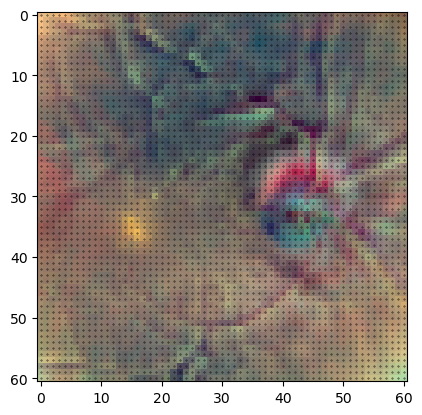

In [30]:
I5_norm = normalize(I_lst[5])
J5_norm = normalize(J_lst[5])

y5 = y_[5]
xy5 = xy_lst[5].numpy()
ind5 = ind_lst[5]
h5 = h_lst[5]
w5 = w_lst[5]

x5, y5 = torch.meshgrid([torch.arange(0,h5).float(), torch.arange(0,w5).float()], indexing='ij')
xy5 = torch.stack([x5,y5],2)

x_coords = xy5[..., 0].flatten()
y_coords = xy5[..., 1].flatten()
diff5 = (I5_norm - J5_norm)
diff5_norm = normalize(diff5)
plt.imshow(diff5_norm.permute(1,2,0).numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.1)



In [31]:
xy5[:10,:10,:].numel() #NOTE get the number of elements in the tensor

200

In [32]:

n_neurons = N_NEURONS
class MINE_INSIDE(nn.Module): # unravel the functioning of the net
    def __init__(self, nChannel: int):
        super(MINE_INSIDE, self).__init__()
        self.fc1 = nn.Linear(2*nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient

    def forward(self, y, ind):
        x = y.view(y.size()[0]*y.size()[1],y.size()[2]) #flatten the tensor to use the rand perm and get random index
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))] # perchè non provare a farlo qua dentro usando torch.randperm(int(len(x[0]*sampling)))
            z1_first = F.relu(self.fc1(x[ind,:]))
            z2_first = self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))
            z1_second = F.relu(self.fc2(z1_first)) 
            z2_second = self.fc2(z2_first)
            z1 = self.fc3(z1_second) 
            z2 = self.fc3(z2_second)
            #z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            #z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))))))
            print(f'''x[ind,0:nChannel] shape : {x[ind,0:nChannel].shape},
                x[ind_perm,nChannel:2*nChannel]shape : {x[ind_perm,nChannel:2*nChannel].shape},
                the input_shape is : {x[ind,:].shape},
                after the first layer the output shape is : {z2_first.shape},
                after the second layer the output shape is : {z1_second.shape},
                the third layer shape : {z2.shape}.
                The original tensor is x: {y.shape}, after the forward pass the shae change into: {x.shape}
                ''')
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize


In [33]:
homography_net = HomographyNet()
Jw5 = AffineTransform(J_lst[5].unsqueeze(0), homography_net(5), xy5[:,:, 0], xy5[:,:, 1]).squeeze()
x =torch.cat([I_lst[5], Jw5], 0).permute(1,2,0)
ind =ind5
mine_net = MINE_INSIDE(nChannel=3)
mi = mine_net(x, ind)
x_new = x.view(x.size()[0]*x.size()[1],x.size()[2])
x_new.shape

x[ind,0:nChannel] shape : torch.Size([372, 3]),
                x[ind_perm,nChannel:2*nChannel]shape : torch.Size([372, 3]),
                the input_shape is : torch.Size([372, 6]),
                after the first layer the output shape is : torch.Size([372, 100]),
                after the second layer the output shape is : torch.Size([372, 100]),
                the third layer shape : torch.Size([372, 1]).
                The original tensor is x: torch.Size([61, 61, 6]), after the forward pass the shae change into: torch.Size([3721, 6])
                


torch.Size([3721, 6])

In [34]:
import torchinfo
minet = MINE(nChannel=3)
s=3
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)
Jws = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:, 0], xy_lst[s][:,:, 1]).squeeze()
x =torch.cat([I_lst[s], Jws], 0).permute(1,2,0)
ind =ind_lst[s]
S_summary = torchinfo.summary(minet, input_data=(x, ind))


In [35]:
S_summary

Layer (type:depth-idx)                   Output Shape              Param #
MINE                                     --                        --
├─Linear: 1-1                            [5904, 100]               700
├─Linear: 1-2                            [5904, 100]               10,100
├─Linear: 1-3                            [5904, 1]                 101
├─Linear: 1-4                            [5904, 100]               (recursive)
├─Linear: 1-5                            [5904, 100]               (recursive)
├─Linear: 1-6                            [5904, 1]                 (recursive)
Total params: 10,901
Trainable params: 10,901
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 128.72
Input size (MB): 1.46
Forward/backward pass size (MB): 18.99
Params size (MB): 0.04
Estimated Total Size (MB): 20.50

tensor([  0.,   0.,   0.,  ..., 485., 485., 485.])

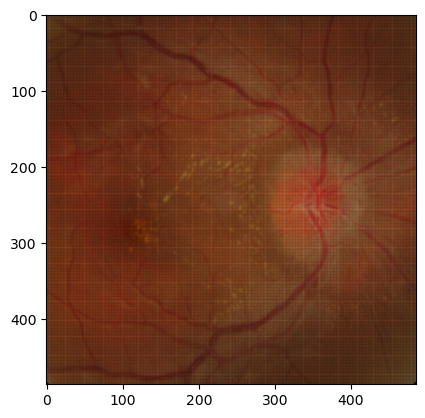

In [36]:
# create a function to visualize the meshgrid or x_, y_ xy_, h_list, w_list, ind_list on the image to see
# # the correspondence between the coordinates' values and the image
import matplotlib.pyplot as plt
import numpy as np

I3 = normalize(I_lst[2])
J3 = normalize(J_lst[2])

y3 = y_[3]
xy3 = xy_lst[2].numpy()
ind3 = ind_lst[2]
h3 = h_lst[2]
w3 = w_lst[2]
x3, y3 = torch.meshgrid([torch.arange(0,h3).float(), torch.arange(0,w3).float()], indexing='ij')
xy3 = torch.stack([x3,y3],2)

x_coords = xy3[..., 0].flatten()
y_coords = xy3[..., 1].flatten()
diff3 = (I3 - J3)
diff3_norm = normalize(diff3)
plt.imshow(I3.permute(1,2,0).numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.001)
x_coords


In [37]:
# rearrange the loss funciton parameter to take inn two objects, the image of the dataset and the predicted through the MINE net 
# per una coppia di immagini :
# train -> loss
# omografia -> loss ...

In [38]:
h = 4
w = h
image = torch.Tensor(np.random.randn(h, w, 3))

index = torch.randperm(int(h*w))


for i in range(len(ind_lst)):
    print(f'the {i}-th element has {len(ind_lst[i])} elements')

the 0-th element has 376748 elements
the 1-th element has 94284 elements
the 2-th element has 23619 elements
the 3-th element has 5904 elements
the 4-th element has 1488 elements
the 5-th element has 372 elements


## Functioning


In [39]:
ground_path = CONTROL_POINTS_FOLDER
control_points = [n for n in list(ground_path.glob('*')) if n.name.__contains__('A01')]
control_points

[WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Ground Truth/control_points_A01_1_2.txt')]

In [40]:
# prendere le coordinate dalla lista dei valori di riferimento

def get_coords(image_name : str, #es A01
               ground_truth_path : Path = CONTROL_POINTS_FOLDER, # in this case: control_points_[Image pair name]_1_2.txt
               )-> tuple[list[list[float]], list[list[float]]]:
    '''
    get the coordinates of control points associate to the image in list of coords format
    the format in the ground truth folder:

        [reference_point_1_x] [reference_point_1_y] [test_point_1_x] [test_point_1_y]

        [reference_point_2_x] [reference_point_2_y] [test_point_2_x] [test_point_2_y]

    it will returns the list of coords for both test(_2) and reference(_1) image in the format test(x,y) ; reference(x,y)
    '''
    if not ground_truth_path.exists():
        raise FileNotFoundError(f'directory {ground_truth_path} not found')
    txt_file_path = [n for n in list(ground_truth_path.glob('*')) if n.name.__contains__(image_name)]
    reference_points, test_points = [], []
    with open(txt_file_path[0], 'r') as file:
        lines = file.readlines()
        for line in lines:
            ref_x, ref_y, test_x, test_y = line.split()
            reference_points.append([float(ref_x), float(ref_y)])
            test_points.append([float(test_x), float(test_y)])
    return test_points, reference_points


ground_path = CONTROL_POINTS_FOLDER
test_points, reference_points = get_coords(image_name='A01') # dato che la valutazione è sull'ultimo è questa quella che dovrebbe pesare di più sulla scala delle MI

In [175]:
get_coords(image_name='A01')

([[388.0, 822.0],
  [357.0, 1849.0],
  [1153.0, 2487.0],
  [1843.0, 400.0],
  [2358.0, 2000.0],
  [2556.0, 1198.0],
  [1949.0, 1194.0],
  [670.0, 1192.0],
  [1944.0, 1460.0],
  [1328.0, 1784.0]],
 [[332.0, 872.0],
  [370.0, 1897.0],
  [1212.0, 2483.0],
  [1761.0, 348.0],
  [2384.0, 1912.0],
  [2527.0, 1099.0],
  [1922.0, 1131.0],
  [642.0, 1222.0],
  [1930.0, 1408.0],
  [1339.0, 1768.0]])

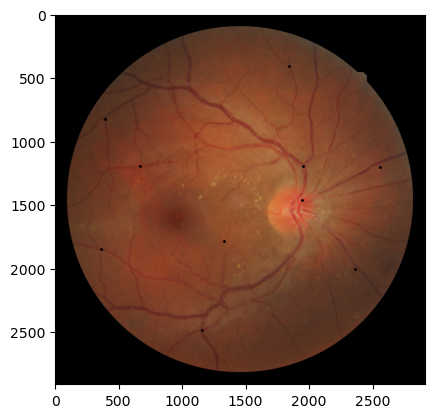

In [42]:
x_test = [test_point[0] for test_point in test_points]
y_test = [test_point[1] for test_point in test_points]
test_to_open = np.asarray(img_ref.squeeze().permute(1,2,0))
plt.scatter(x_test, y_test, c='black', s=1)
plt.imshow(test_to_open)

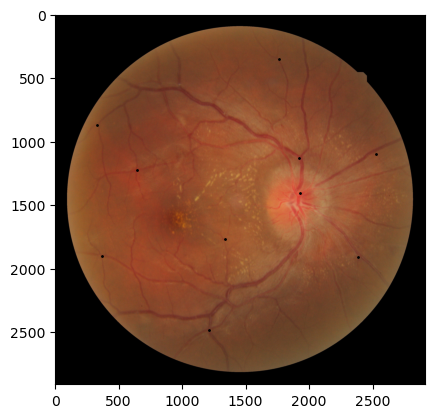

In [43]:
x_ref = [reference_point[0] for reference_point in reference_points]
y_ref = [reference_point[1] for reference_point in reference_points]
ref_to_open = np.asarray(img_test.squeeze().permute(1,2,0))
plt.scatter(x_ref, y_ref, c='black', s=1)
plt.imshow(ref_to_open)

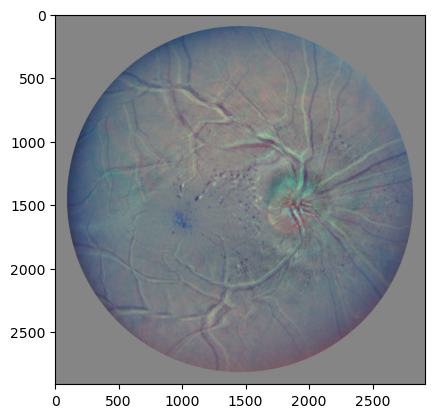

In [44]:
im_ref = normalize(img_ref.squeeze().permute(1,2,0))
im_test = normalize(img_test.squeeze().permute(1,2,0))
im = normalize(im_ref - im_test)
plt.imshow(im)


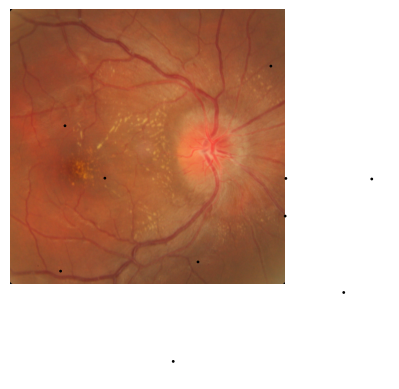

In [45]:
s = 0
Is = normalize(I_lst[s])
Js = normalize(J_lst[s])

ys = y_[s]
xys = xy_lst[s].numpy()
inds = ind_lst[s]
hs = h_lst[s]
ws = w_lst[s]
xs, ys = torch.meshgrid([torch.arange(0,hs).float(), torch.arange(0,ws).float()], indexing='ij')
xys = torch.stack([xs,ys],2)

x_coords = xys[..., 0].flatten()
y_coords = xys[..., 1].flatten()
x_test = [test_point[0] for test_point in test_points]
y_test = [test_point[1] for test_point in test_points]

diffs = (Is - Js)
diffs_norm = normalize(diffs)
# creare una funzione per visualizzare i punti di riferimento e le corrispondenze tra i punti di riferimento e le immagini
def show_image_and_reference_points(s: int, 
                                    coordinates: list[list[float]],
                                    title : str = get_data_time(),
                                    uniform_color : bool = True,
                                    image: torch.Tensor = Is,):
    x_test = [test_point[0] for test_point in coordinates]
    y_test = [test_point[1] for test_point in coordinates]
    result_image_folder = Path.cwd().parent / 'Results' /'ImgRes'
    plt.imshow(image.permute(1,2,0).numpy())
    plt.axis('off')
    if not uniform_color:
        colors = plt.cm.jet(np.linspace(0, 1, len(coordinates)))
    else: 
        colors = ['black'] * len(coordinates)
    '''for i, (x, y) in enumerate(coordinates):
        plt.scatter(x, y, c=colors[i], s=1)'''
    plt.scatter(x_test, y_test, c=colors, s=1)
    plt.savefig(result_image_folder / f'{title}.png')


show_image_and_reference_points(s=0, coordinates=test_points)


In [46]:
#non tutti i punti sono papabili, pertanto bisogna tolgiere quelli che sono out of the box: (1.5/9. - 7.5/9) * shape image
xshape, yshape = ORIGINAL_SHAPE
test_points, reference_points
def remove_coord_outside_box(coords : list[list[float]],
                            original_shape : tuple[int] = ORIGINAL_SHAPE,
                            upper_edge: float = 7.5/9.,
                            lower_edge: float = 1.5/9.,
                            )-> list[list[float]]:
    '''
    remove the coordinates that are outside the box of the cropped image
    '''
    xshape, yshape = original_shape
    print(f'xshape: {xshape}, yshape: {yshape}')
    modified_coords = []
    xlimit, ylimit = int(xshape*upper_edge), int(yshape*upper_edge)
    xbase, ybase = int(xshape*lower_edge), int(yshape*lower_edge)
    
    for coord in coords:
        x_coord , y_coord = coord
        if x_coord not in range(xbase, xlimit +1):
            print(f'since {x_coord} is outside the box, {x_coord, y_coord} will be removed') # logging
            continue
        elif y_coord not in range(ybase, ylimit +1):
            print(f'since {y_coord} is outside the box, {x_coord, y_coord} will be removed') #logging
            continue
        else:
            x_coord -= xbase
            y_coord -= ybase
            print(f'the new coord are {x_coord}, {y_coord}')#logging
            coord = (x_coord, y_coord)
            modified_coords.append(coord)

    return modified_coords


# if just one of the value in the coords is outside the box of the image, it should be removed
# then remove from both x and y coords the min value of  1.5/9.*shape[0] to reassest the coords in the visualization
# remember to pack two tuple of coords in the list to get the evaluation, just after the crop and before it.

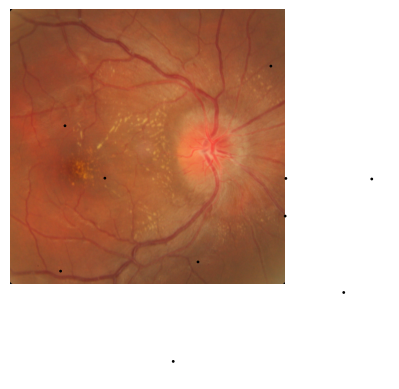

In [47]:
show_image_and_reference_points(s=0, coordinates=test_points, title='Is_and_test_points')

xshape: 2912, yshape: 2912
since 388.0 is outside the box, (388.0, 822.0) will be removed
since 357.0 is outside the box, (357.0, 1849.0) will be removed
since 2487.0 is outside the box, (1153.0, 2487.0) will be removed
since 400.0 is outside the box, (1843.0, 400.0) will be removed
the new coord are 1873.0, 1515.0
since 2556.0 is outside the box, (2556.0, 1198.0) will be removed
the new coord are 1464.0, 709.0
the new coord are 185.0, 707.0
the new coord are 1459.0, 975.0
the new coord are 843.0, 1299.0
xshape: 2912, yshape: 2912
since 332.0 is outside the box, (332.0, 872.0) will be removed
since 370.0 is outside the box, (370.0, 1897.0) will be removed
since 2483.0 is outside the box, (1212.0, 2483.0) will be removed
since 348.0 is outside the box, (1761.0, 348.0) will be removed
the new coord are 1899.0, 1427.0
since 2527.0 is outside the box, (2527.0, 1099.0) will be removed
the new coord are 1437.0, 646.0
the new coord are 157.0, 737.0
the new coord are 1445.0, 923.0
the new coor

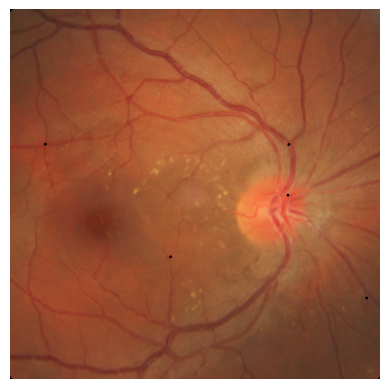

In [48]:
cropped_test_points = remove_coord_outside_box(test_points)
cropped_reference_points = remove_coord_outside_box(reference_points)
show_image_and_reference_points(s=0, coordinates=cropped_test_points, image=Js, title='Js_and_cropped_test_points')

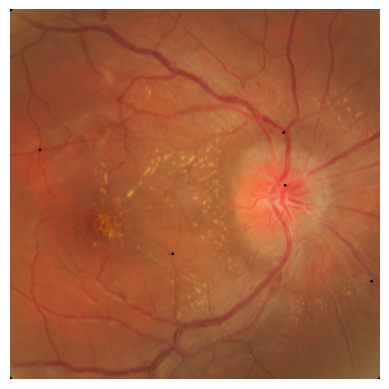

In [49]:
show_image_and_reference_points(s=0, coordinates=cropped_reference_points, title='Is_and_reference_points') # Is and reference points

In [50]:
def AffineTransform(I, H, xv, yv):
    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze()
    return J # it's torch.Tensor type
xv = torch.Tensor([x[0] for x in cropped_test_points])
yv = torch.Tensor([x[1] for x in cropped_test_points])
homography_net = HomographyNet()
homo_matrix = homography_net(0)


In [51]:
loss_vals = []
for s in np.arange(5, -1, -1):
    Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
    print(f'Jw_ shape is {Jw_.shape}')
    loss_val = torch.cat([I_lst[s], Jw_], 0)
    loss_vals.append(loss_val)

Jw_ shape is torch.Size([3, 61, 61])
Jw_ shape is torch.Size([3, 122, 122])
Jw_ shape is torch.Size([3, 243, 243])
Jw_ shape is torch.Size([3, 486, 486])
Jw_ shape is torch.Size([3, 971, 971])
Jw_ shape is torch.Size([3, 1941, 1941])


In [52]:
def get_warped_coords(test_coords:torch.Tensor |np.ndarray, 
                      affine_matrix,
                      )->tuple[list[int, int]]:
    
    '''Get the warped coordinates applying the homography matrix to the test coordinates
    Parameters:
    test_coords : torch.Tensor | np.ndarray
        the coordinates to be transformed, shape (N, 2)
    affine_matrix 
        the homography matrix, shape (3, 3)
        
    Returns:
    tuple[list[int, int]]
        the transformed coordinates as list of integer tuples'''
    ones = torch.ones(test_coords.shape[0], 1)
    #print(f'ones is : \n{ones}  of shape {ones.shape}\n\n')
    homogeneous_points = torch.cat([test_coords, ones], dim=1)
    #print(f'homogeneous_points is : \n{homogeneous_points} of shape {homogeneous_points.shape}\n\n')
    # Apply homography
    transformed_points = torch.matmul(homogeneous_points, affine_matrix.T)
    #print(f'affine matrix is : \n{affine_matrix} of shape \t{affine_matrix.shape}\n\n')
    #print(f'transformed_points are : \n{transformed_points} of shape \t{transformed_points.shape}\n\n')
    # Convert back to Cartesian coordinates
    transformed_points = transformed_points[:, :2] / transformed_points[:, 2].unsqueeze(1)
    transformed_points_int_list = [[int(round(x)), int(round(y))] for x, y in transformed_points.tolist()]
    
    return transformed_points_int_list

# Esempio di utilizzo
test_coords =cropped_reference_points
transformed_points = get_warped_coords(torch.Tensor(test_coords), homo_matrix)
transformed_points,cropped_reference_points # verificato che siano uguali

([[1899, 1427], [1437, 646], [157, 737], [1445, 923], [854, 1283]],
 [(1899.0, 1427.0),
  (1437.0, 646.0),
  (157.0, 737.0),
  (1445.0, 923.0),
  (854.0, 1283.0)])

In [53]:
homo_matrix

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], grad_fn=<AddBackward0>)

In [54]:
# creare una funzione per la loss e valutarla in merito a tali punti
def loss_reference_points(reference_list : list[[int, int]], # for I image
                          homography_matrix : torch.Tensor,
                          test_list : list[[int, int]], # for J image
                          ) -> float :
    ''' given two list of coordinates, it get the euclidean distance between these two:
    calculated as the difference between the test point and the affine transformation of the coordinate through the homography tensor
    Args:
        reference_list (list[[int, int]]): list of coordinate points of the image of reference
        test_list (list[[int, int]]): list of coordinate points of the image to test the homography on
        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss 
    '''
    if len(reference_list) != len(test_list):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.0
        test_coords = get_warped_coords(torch.Tensor(test_list), homography_matrix)
        for i in range(len(reference_list)):
            x_ref, y_ref = reference_list[i]
            x_test, y_test = test_coords[i]
            loss += np.sqrt((x_ref - x_test)**2 + (y_ref - y_test)**2)
        return loss

# creare una funzione per la loss e valutarla in merito al valore in tali punti
def loss_value_points(reference_points : list[[int, int]],  # for the  I image
                          test_points : list[[int, int]], # for the J image
                          reference_image : torch.Tensor, # for the I image
                          warped_image : torch.Tensor, # for the Jimage
                          homography_matrix : torch.Tensor,
                          ) -> float :
    ''' 
    given two list of coordinates(reference_points), 
    it get the differences in values between the test image and the warped one in these coordinates

    Assume that all the images both the fixed and the warped one are both of same shape and resulted from the dataloader,
    ready to be processed by the net of shape [3, N ,N] or [N ,N]

    Args:
        reference_points (list[[int, int]]): list of coordinate points of the image of reference I

        test_points (list[[int, int]]): list of coordinate points of the image to test the homography on J

        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss H

        reference_image the image of reference I

        warped_image the image to be tested J
    '''
    if len(reference_points) != len(test_points):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.
        test_coords = get_warped_coords(torch.Tensor(test_points), homography_matrix)

        for i in range(len(reference_points)):
            x_ref, y_ref = reference_points[i] 
            x_test, y_test = test_coords[i]
            if np.min(reference_image.shape) == 3: # nChannel==3
                reference_value = torch.sum(reference_image[:, x_ref, y_ref]).item()
                warped_value = torch.sum(warped_image[:, x_test, y_test]).item()

            else:
                reference_value = reference_image[x_ref, y_ref].item()
                warped_value = warped_image[x_test, y_test].item()
            loss += np.abs(reference_value - warped_value)
        return loss

def loss_value_images(I : torch.Tensor,
                      J : torch.Tensor,
                      shape_independece : bool = True,
                      )-> float:
    ''' get the loss value between two images'''
    if I.shape != J.shape:
        raise ValueError("the two images must have the same shape")
    else:
        if np.min(I.shape) == 1:
            I = I.squeeze()
            J = J.squeeze()
        I_norm = normalize(I)
        J_norm = normalize(J)
        if shape_independece:
            shape_normalizator = I.shape[0] * I.shape[1]
            return torch.abs(I_norm - J_norm).sum()/shape_normalizator
        else:
            return torch.abs(I_norm - J_norm).sum()

def mse_loss(img_fixed: np.ndarray | torch.Tensor,
             img_moving: np.ndarray |torch.Tensor,
             )-> float:
    ''' get the mean squared error loss between two images
    
    Parameter:
    img_fixed (np.ndarray | torch.Tensor): the fixed image
    img_moving (np.ndarray | torch.Tensor): the moving image
    
    Returns:
    float: the mean squared error loss between the two images, normalized over their size
    '''

    if img_fixed.shape != img_moving.shape:
        raise ValueError("the two images must have the same shape")
    if type(img_fixed) != type(img_moving):
        raise TypeError("the two images must have the same type")
    elif isinstance(img_fixed, torch.Tensor):
        img_fixed = img_fixed.squeeze().permute(1,2,0).numpy()
        img_moving = img_moving.squeeze().permute(1,2,0).numpy()


    return np.sum((img_fixed - img_moving)**2)/img_fixed.size

def mutual_information_loss(fixed_image: np.ndarray | torch.Tensor,
                            warped_image : np.ndarray | torch.Tensor,
                            index_list: torch.Tensor,
                            mine_net : MINE,
)-> float :
    '''
    the loss calculate through the mutual information between the two pyramids
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        the fixed image as reference or ground truth
    warped_image : np.ndarray | torch.Tensor
        the warped image as the input
    index_list : list[torch.Tensor]
        the index list to be used to calculate the mutual informationLoss 
    mien_net : MINE 
        the MINE network to be used to calculate the mutual informationLoss
    '''
    mi_loss = 0.0
    if fixed_image.shape != warped_image.shape:
        raise ValueError("the two images must have the same shape")
    if type(fixed_image) != type(warped_image):
        raise TypeError("the two images must have the same type")
    elif isinstance(fixed_image, np.ndarray):
        fixed_image = torch.from_numpy(fixed_image)
        warped_image = torch.from_numpy(warped_image)
    if fixed_image.ndim == 2:
        mi_loss = mine_net(torch.stack([fixed_image, warped_image], 2), index_list)
    else:
        mi_loss = mine_net(torch.cat([fixed_image, warped_image], 0).permute(1,2,0), index_list)
    return mi_loss      

def pyramid_mi_loss(fixed_pyramid : list[torch.Tensor],
                    warped_pyramid : list[torch.Tensor],
                    index_list :list,
                    mine_net : MINE,
                    ) -> float :
    '''
    the function perform the mutual loss calculation over the pyramid of images

    Parameters :
        fixed_pyramid : list of different resolution images for references

        warped_pyramid : list of different resolution images for warped images

        index_list : list of indices for the homography transformation, indicate the coordinates of points in image pairs

        mine_net the network to calculate the mi_loss 

    Returns :
        the mutual information loss between the two pyramids of images
            '''     
    if len(fixed_pyramid) != len(warped_pyramid) != len(index_list):
        raise ValueError("the two pyramids and the index list must have the same length ")   
    mi_loss = 0.0
    L = len(fixed_pyramid)
    for s in np.arange(L-1, -1, -1):
        mi_loss -= mutual_information_loss(fixed_image=fixed_pyramid[s], warped_image=warped_pyramid[s], index_list=index_list[s], mine_net=mine_net)/L

    return mi_loss

#### Gli altri metodi di valutazione per le singole immagini, da usare in due varianti:
    1. per le immagini B/N
    2. per le immagini colorate



In [55]:
import SimpleITK as sitk
import torch
# MMI MATTES MUTUAL INFORMATION - usa la PARZEN WINDOW dai metodi di SimpleITK
def mattes_mutual_information(image1: np.ndarray | torch.Tensor, # consider the images as bn or monochanneled
                              image2: np.ndarray | torch.Tensor,
                              num_bins : int = 100,
                              parzen_kernel : float = 1.0,
)-> float:
    '''
    la funzione calcola a partire da due immagini in formato numpy o tensore la mutual information nella definizione di Mattes
    ci si serve della finestra di parzen per l'approssimazione a una distribuzione continua, al fine di ottenere un risultato meno influenzato
    dalla distribuzione discreta dei pixels

    PARAMETERS
        - image1 & image2: the reference and warped image
        - num_bins: num of bins to consider to obtain the histogram
        - parzen_kernel: the kernel size to get the continuous approximation of histogram values

    RETURN
        - MMI: a float as mattes' mutual information
    '''
    pass

    # PARZEN windowing - usa la finestra di Parzen per ridurre l'effetto di quantizzazione sull'istogramma, dai metodi di SimpleITK ...
    # convert the image type from numpy to torch.Tensor if necessary
    if isinstance(image1, np.ndarray):
        image1 = torch.from_numpy(image1)
    if isinstance(image2, np.ndarray):
        image2 = torch.from_numpy(image2)
    if image1.shape != image2.shape:
        raise ValueError("The two images must have the same shape")
    
    image1 = image1.view(-1)  # flatten the image
    image2 = image2.view(-1)  # flatten the image
    #normalization
    image1 = (image1 - image1.min()) / (image1.max() - image1.min())
    image2 = (image2 - image2.min()) / (image2.max() - image2.min())

    # create binning centers
    bin_centers = torch.linspace(0, 1, num_bins) #NOTE inseguito se usi device usa device = image1.device
     
    def parzen_windowing(z):
        '''
        define the approssimation using a gaussian kernel
        '''
        return  torch.exp(-0.5 * ((z[:, None] - bin_centers[None, :]) / parzen_kernel)**2)
    
    px=parzen_windowing(image1)
    py=parzen_windowing(image2)

    # calculate margianl and joint probabilities
    pxy = torch.mm(px.T, py)  # joint histogram
    pxy /= pxy.sum()  # normalize to get probabilities

    px_marginal = px.sum(dim=0)/px.shape[0]  # marginal for image1
    py_marginal = py.sum(dim=0)/py.shape[0]  # marginal for image2
    px_py = px_marginal[:, None] * py_marginal[None, :]  # outer product for joint marginal probabilities

    nzs = pxy > 0  # non-zero elements
    # calculate mutual information
    mmi = torch.sum(pxy[nzs] * torch.log(pxy[nzs] / px_py[nzs]))  # mutual information
    return mmi.item()  # return as float




# Joint hinstogram mutual information, usa un istogramma per appiattire e calcolare le immagini similmente alla NMI, dai metodi di SimpleITK?
def histogram_mutual_information(image1, image2):
    hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hgram / float(np.sum(hgram))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

def JHMI_itk(fixed_image: np.ndarray | torch.Tensor,):
    pass


# Normalized cross correlation, usa la correlazione incrociata normalizzata per calcolare la similarità tra le immagini, dai metodi di SimpleITK ...
def nccITK(fixed_image: np.ndarray | torch.Tensor,
           warped_image: np.ndarray | torch.Tensor,
           )-> float:
    '''
    Normalized Cross Correlation (NCC) between two images.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = fixed_image.detach().cpu().numpy()
    if isinstance(warped_image, torch.Tensor):
        warped_image = warped_image.detach().cpu().numpy()

    fixed_sitk = sitk.GetImageFromArray(fixed_image.astype(np.float32))
    warped_sitk = sitk.GetImageFromArray(warped_image.astype(np.float32))
    
    ncc_filter = sitk.FFTNormalizedCorrelationImageFilter()
    ncc_map = ncc_filter.Execute(fixed_sitk, warped_sitk)

    stats = sitk.StatisticsImageFilter()
    stats.Execute(ncc_map)
    return stats.GetMaximum()  # Return the maximum NCC value

# Mean Squared Error, usa la differenza quadratica media per calcolare la similarità tra le immagini, dai metodi di SimpleITK ...
def mse_sitk(fixed_image: np.ndarray | torch.Tensor,
                     warped_image: np.ndarray | torch.Tensor,
                     )-> float:
    '''
    Mean Squared Error (MSE) between two images.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The mean squared error value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = fixed_image.detach().cpu().numpy()
    if isinstance(warped_image, torch.Tensor):
        warped_image = warped_image.detach().cpu().numpy()

    fixed_sitk = sitk.GetImageFromArray(fixed_image.astype(np.float32))
    warped_sitk = sitk.GetImageFromArray(warped_image.astype(np.float32))
    
    mse_filter = sitk.MeanSquaresImageFilter()
    mse_value = mse_filter.Execute(fixed_sitk, warped_sitk)

    return mse_value  # Return the MSE value

# Airlab mutual infromation usa la mutual information per calcolare la similarità tra le immagini, dai metodi di AirLab


#  Normalized Mutual Information, usa la mutual information normalizzata per calcolare la similarità tra le immagini, dai metodi di SimpleElastix ...



#### Metodi SITK per la image registration :


In [56]:
A01_test = test_images_path / 'Longitudinal_Studies' / 'A01_2.jpg'
A01_reference = reference_images_path / 'Longitudinal_Studies' / 'A01_1.jpg'

In [57]:
def tensor_img_to_sitk(img : torch.Tensor
                       )-> sitk.Image:
    '''
    convert a torch tensor image to a SimpleITK image
    '''
    img = img.squeeze().detach().cpu().numpy()
    if img.ndim == 2: # single channel image
        img = img 
    if img.ndim == 3 and img.shape[0] == 3: # multi-channel image
       img = np.transpose(img, (1, 2, 0)) # change to (H, W, C) format
       rgb_to_gray_sensitivity = [0.2898, 0.5870, 0.1140] # RGB to gray sensitivity
       img = np.dot(img, rgb_to_gray_sensitivity) # convert to grayscale
    return sitk.GetImageFromArray(img.astype(np.float32)) # convert to SimpleITK image

In [58]:
img_ref_sitk = tensor_img_to_sitk(img_ref)

### MAttes mutual information from SITK
TODO to pass the registration function in an object oriented programming

In [59]:
# MATTEs MUtual INformation:
def MMI_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              ): # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Mattes mutual information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_sitk = sitk.ReadImage(fixed_image, sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_sitk = sitk.ReadImage(warped_image)
    if isinstance(fixed_image, torch.Tensor):
        fixed_sitk = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_sitk = tensor_img_to_sitk(warped_image)


    samplingPercentage = 0.10
    
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()
    registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=100)  #FIXME numberOfHistogramBins as parameter
    registration.SetMetricSamplingPercentage(samplingPercentage, sitk.sitkWallClock) # NOTE see if optional or a must
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetOptimizerAsRegularStepGradientDescent(learningRate=0.1, minStep=0.001, numberOfIterations=200) # NOTE the parameters have to be the same from the aritcle
    registration.SetInitialTransform(sitk.AffineTransform(fixed_sitk.GetDimension()))  # Initial transform
    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator

    #    registration.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration)) # to get the iteration information while executing the cycle

    # to get the transformation of the warped image:
    outTx = registration.Execute(fixed_sitk, warped_sitk)  # Execute the registration

    # get information about the iteration cycle:

    return outTx, registration


In [60]:

imagedir_save_path = Path.cwd().parent / 'Results' / 'ImgRes'
imagedir_save_path.exists()

True

In [61]:
imagedir_save_path = Path.cwd().parent / 'Results' / 'ImgRes'

def get_image_confrontation_SITK(image_ref : sitk.Image | torch.Tensor, 
                   image_test : sitk.Image | torch.Tensor,
                   outTx : sitk.Transform,
                   interpolator = sitk.sitkLinear,
                   default_pxv : int = 100,
                   visualize: bool = True,
                   folder_path: Path = imagedir_save_path, 
                   name: str = 'A01_sitk'                  
                   )-> sitk.Image:
    '''
    get the warped image and the fixed image from the SimpleITK images and the transformation matrix
    '''
    if isinstance(image_ref, torch.Tensor):
        image_ref = tensor_img_to_sitk(image_ref)
    if isinstance(image_test, torch.Tensor):
        image_test = tensor_img_to_sitk(image_test)

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(image_ref)  # Set the reference image
    resampler.SetTransform(outTx)  # Set the transformation
    resampler.SetInterpolator(interpolator)  # Set the interpolator
    resampler.SetDefaultPixelValue(default_pxv)  # Set the default pixel value

    outcome_image = resampler.Execute(image_test)  # Execute the resampling
    sigm1 = sitk.Cast(sitk.RescaleIntensity(outcome_image), sitk.sitkUInt8)
    sigm2 = sitk.Cast(sitk.RescaleIntensity(image_ref), sitk.sitkUInt8)
    image_confrontation = sitk.Compose(sigm1, sigm2, sigm1//2.0 + sigm2//2.0)  # Compose the two images

    if visualize:
        array_image = sitk.GetArrayFromImage(image_confrontation)  # Convert to numpy array for visualization
        if array_image.shape[0] in (1, 3):  # se è un'immagine monocromatica o RGB
            array_image = np.moveaxis(array_image, 0, -1)
        plt.figure(figsize=(6, 6))
        plt.imshow(array_image, cmap='gray')
        plt.axis('off')
        plt.title("Warped and Fixed Image")
        plt.show()
        plt.savefig(folder_path / f'{name}.png')
    return image_confrontation

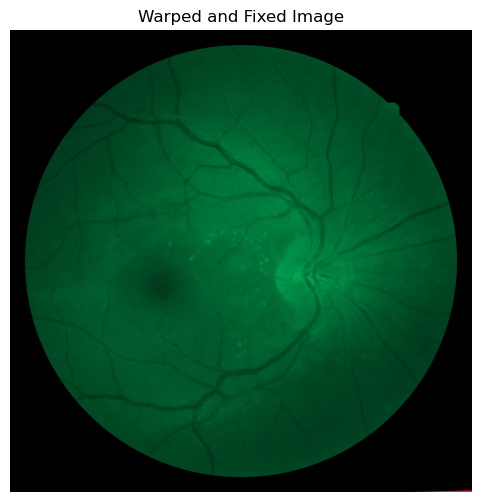

<Figure size 640x480 with 0 Axes>

In [62]:
transformation_mmi_sitk, registration_sitk = MMI_SITK(fixed_image=img_ref, 
                                     warped_image=img_test)

A01_MMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                            image_test=tensor_img_to_sitk(img_test),
                                            outTx=transformation_mmi_sitk,
                                            name='A01_MMI_sitk',
                                            folder_path=imagedir_save_path,
                                            visualize=True)

# NOTE use registration_sitk to get information on registration process: 

In [63]:
def get_affine_matrix_from_sitk_transform(sitk_transform: sitk.AffineTransform
                                          )-> torch.Tensor:
    '''
    get the homogeneous affine matrix from the SimpleITK transform object
    as a torch.Tensor
    H = | M t_eff |
        | c   1   |
    where t_eff = t + c - M @ c as effective translation considering the center of rotation
    and M is the rotation matrix, t is the translation vector, c is the center of rotation
    ---------------
    '''
    dim = sitk_transform.GetDimension()
    M = np.array(sitk_transform.GetMatrix(), dtype=float).reshape((dim, dim))
    t = np.array(sitk_transform.GetTranslation(), dtype=float)
    c = np.array(sitk_transform.GetCenter(), dtype=float)  

    # compute the effective translation considering the center of rotation
    t_eff = t + c - M @ c
    # construct the homogeneous affine matrix
    H = torch.eye(dim + 1, dtype=torch.float32)
    H[:dim, :dim] = torch.Tensor(M)
    H[:dim, dim] = torch.Tensor(t_eff)


    return H

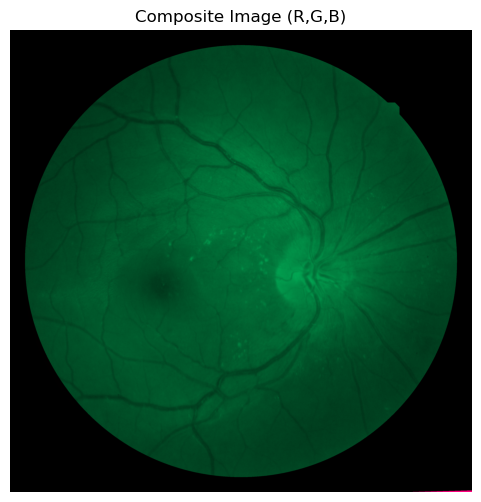

In [64]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(img_ref_sitk) # NOTE param
resampler.SetTransform(transformation_mmi_sitk) # NOTE param
resampler.SetInterpolator(sitk.sitkLinear)  # Interpolator
resampler.SetDefaultPixelValue(100)  # Default pixel value for the output image

out = resampler.Execute(tensor_img_to_sitk(img_test))  #NOTE param
simg1 = sitk.Cast(sitk.RescaleIntensity(out), sitk.sitkUInt8)  # Rescale the intensity to uint8
simg2 = sitk.Cast(sitk.RescaleIntensity(img_ref_sitk), sitk.sitkUInt8)  # Rescale the intensity to uint8
cimg = sitk.Compose(simg1, simg2, simg1//2.0 + simg2//2.0)  # Compose the images
# if plot_composite_image:
# plot...
arr = sitk.GetArrayFromImage(cimg)

# 2) Riordina i canali in ultima dimensione:
#    da (bands, H, W) a (H, W, bands)
if arr.shape[0] in (1, 3):  # se è un'immagine monocromatica o RGB
    arr = np.moveaxis(arr, 0, -1)

# 3) Se i tuoi dati non sono già uint8, normalizza/castali:
# arr = (255.0*(arr - arr.min())/(arr.max()-arr.min())).astype(np.uint8)

# 4) Mostra con matplotlib
plt.figure(figsize=(6,6))
plt.imshow(arr, cmap='gray')
plt.axis('off')
plt.title('Composite Image (R,G,B)')
plt.show()


# return cimg

### NCC from SimpleITK: variation with centered

In [65]:

#Ncc for sitk:
def Centred_NCC_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              ): # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_image = tensor_img_to_sitk(warped_image)


    
    
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()

    registration.SetMetricAsCorrelation()  
    registration.SetOptimizerAsRegularStepGradientDescent(
        learningRate=2.0,
        minStep=1e-4,
        numberOfIterations=500,
        gradientMagnitudeTolerance=1e-8,
    )
    registration.SetOptimizerScalesFromIndexShift()
    
    transformation = sitk.CenteredTransformInitializer( fixed_image, warped_image, sitk.AffineTransform(fixed_image.GetDimension())) # TRY to use operation_mode = MOMENTS
    registration.SetInitialTransform(transformation)

    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
    out_tx = registration.Execute(fixed_image, warped_image)  # Execute the registration
    
    

    # get information about the iteration cycle:

    return out_tx, registration


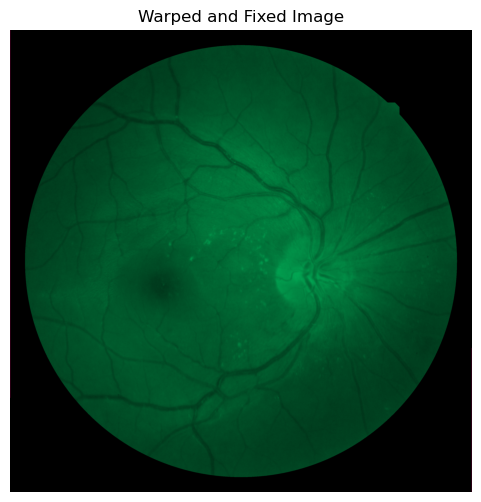

<Figure size 640x480 with 0 Axes>

In [66]:
imagedir_save_path = Path.cwd().parent / 'Results' / 'ImgRes'

transformation_ncc_centred_sitk, registration_Ncc_centred_sitk = Centred_NCC_SITK(fixed_image=img_ref, 
                                     warped_image=img_test)

A01_NMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                            image_test=tensor_img_to_sitk(img_test),
                                            outTx=transformation_ncc_centred_sitk,
                                            name='A01_ncc_centred_sitk',
                                            folder_path=imagedir_save_path,
                                            visualize=True)

### Joint Hinstogram Mutual Information

In [67]:
# MATTEs MUtual INformation:
def JHMI_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              ): # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_image = tensor_img_to_sitk(warped_image)

    # normalization & Gaussian smoothing:
    fixed_image = sitk.DiscreteGaussian(sitk.Normalize(fixed_image), 2.0)
    warped_image = sitk.DiscreteGaussian(sitk.Normalize(warped_image), 2.0)
    
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()

    registration.SetMetricAsJointHistogramMutualInformation(numberOfHistogramBins=100)  
    registration.SetOptimizerAsGradientDescentLineSearch(
        learningRate=1.0e-1,
        numberOfIterations=200, #metti 5000
        convergenceMinimumValue=1e-9,
        convergenceWindowSize=200,

    )
    registration.SetInitialTransform(sitk.AffineTransform(fixed_image.GetDimension()))  # Initial transform
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(0.50)  # 50% sampling
    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
    out_tx = registration.Execute(fixed_image, warped_image)  # Execute the registration   

    return out_tx, registration


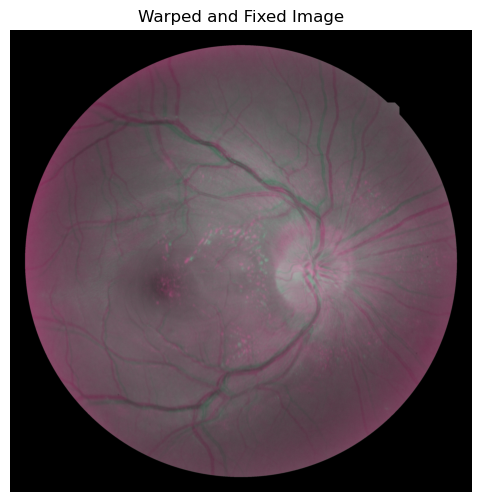

<Figure size 640x480 with 0 Axes>

In [68]:
transformation_JHMI_sitk, registration_JHMI_sitk = JHMI_SITK(fixed_image=img_ref, 
                                     warped_image=img_test)
A01_JHMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                            image_test=tensor_img_to_sitk(img_test),
                                            outTx=transformation_JHMI_sitk,
                                            name='A01_JHMI_sitk',
                                            folder_path=imagedir_save_path,
                                            default_pxv=1,
                                            visualize=True)

In [69]:
registration_JHMI_sitk.GetMetricValue(), registration_JHMI_sitk.GetOptimizerIteration(), registration_JHMI_sitk.GetOptimizerStopConditionDescription()  

(-2.388593657214269,
 199,
 'GradientDescentLineSearchOptimizerv4Template: Convergence checker passed at iteration 199.')

### MSE sitk

In [70]:
# MATTEs MUtual INformation:
def MSE_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              ): # NOTE see the output
    '''
    Mean Squared Error (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_image = tensor_img_to_sitk(warped_image)

    
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()

    registration.SetMetricAsMeanSquares()  
    registration.SetOptimizerAsGradientDescent(
        learningRate = 1.0e-6,
        numberOfIterations = 200,
        convergenceMinimumValue = 1.0e-9,
        convergenceWindowSize = 200,

    )
    registration.SetInitialTransform(sitk.AffineTransform(fixed_image.GetDimension()))  # Initial transform

    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
    out_tx = registration.Execute(fixed_image, warped_image)  # Execute the registration   

    return out_tx, registration


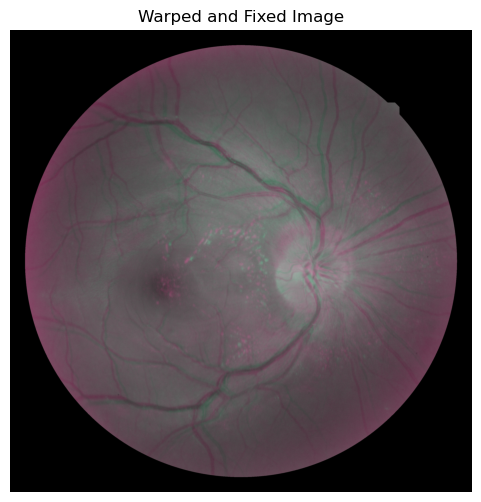

<Figure size 640x480 with 0 Axes>

In [71]:
transformation_MSE_sitk, registration_MSE_sitk = MSE_SITK(fixed_image=img_ref, 
                                     warped_image=img_test)
A01_MSE_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                            image_test=tensor_img_to_sitk(img_test),
                                            outTx=transformation_MSE_sitk,
                                            name='A01_MSE_sitk',
                                            folder_path=imagedir_save_path,
                                            visualize=True)



In [72]:
registration_MSE_sitk.GetMetricValue(), registration_MSE_sitk.GetOptimizerIteration(), registration_MSE_sitk.GetOptimizerStopConditionDescription()  

(0.003126977810058802,
 200,
 'GradientDescentOptimizerv4Template: Maximum number of iterations (200) exceeded.')

### NCC registration for Sitk

In [73]:
def NCC_sitk(fixed_image: np.ndarray | torch.Tensor | Path,
             warped_image: np.ndarray | torch.Tensor | Path,
           )-> float:
    '''
    Registration of two images using Normalized Cross Correlation (NCC) of SimpleITK as metric.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_image = tensor_img_to_sitk(warped_image)

    samplingPercentage = 0.10
    
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()
    registration.SetMetricAsCorrelation()  # NCC metric
    #registration.SetMetricSamplingPercentage(samplingPercentage, sitk.sitkWallClock)  NOTE see if optional or a must
    #registration.SetMetricSamplingStrategy(registration.RANDOM) NOTE not defined in the article
    registration.SetOptimizerAsRegularStepGradientDescent(learningRate=0.1, minStep=0.001, numberOfIterations=200) # NOTE the parameters have to be the same from the aritcle
    registration.SetInitialTransform(sitk.AffineTransform(fixed_image.GetDimension()))  # Initial transform
    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator

    #    registration.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration)) # to get the iteration information while executing the cycle

    # to get the transformation of the warped image:
    outTx = registration.Execute(fixed_image, warped_image)  # Execute the registration
    return outTx, registration

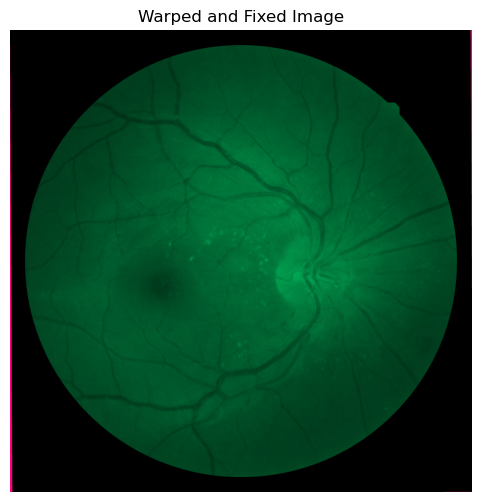

<Figure size 640x480 with 0 Axes>

In [74]:
transformation_ncc_sitk, registration_ncc_sitk = NCC_sitk(fixed_image=img_ref, 
                                     warped_image=img_test)

A01_NCC_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                            image_test=tensor_img_to_sitk(img_test),
                                            outTx=transformation_ncc_sitk,
                                            name='A01_NCC_sitk',
                                            folder_path=imagedir_save_path,
                                            visualize=True)

In [75]:
print(registration_Ncc_centred_sitk)
print(registration_ncc_sitk)

itk::simpleImageRegistrationMethod
  Debug: 0
  NumberOfThreads: 16
  NumberOfWorkUnits: 0
  Commands: (none)
  ProgressMeasurement: 0
  ActiveProcess: (none)
  Interpolator: Linear
  Transform: itk::simple::Transform
 AffineTransform (0000017FC2945B90)
   RTTI typeinfo:   class itk::AffineTransform<double,2>
   Reference Count: 2
   Modified Time: 1699485
   Debug: Off
   Object Name: 
   Observers: 
     none
   Matrix: 
     1.00037 0.000284531 
     -2.1955e-05 1.00014 
   Offset: [-1.15957, -0.163748]
   Center: [1475.26, 1437.96]
   Translation: [-0.19827, 0.00624764]
   Inverse: 
     0.999626 -0.000284384 
     2.19437e-05 0.999859 
   Singular: 0


itk::simpleImageRegistrationMethod
  Debug: 0
  NumberOfThreads: 16
  NumberOfWorkUnits: 0
  Commands: (none)
  ProgressMeasurement: 0
  ActiveProcess: (none)
  Interpolator: Linear
  Transform: itk::simple::Transform
 AffineTransform (0000017FC2945590)
   RTTI typeinfo:   class itk::AffineTransform<double,2>
   Reference Count: 2
 

### NCC SITK from chatgptm

In [76]:
def ncc_sitk_chatgpy(fixed_image: np.ndarray | torch.Tensor | Path | sitk.Image,
           warped_image: np.ndarray | torch.Tensor | Path | sitk.Image,
           transform : sitk.Transform

           )-> float:
    '''
    Normalized Cross Correlation (NCC) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    
    if isinstance(fixed_image, Path):
        fixed_sitk = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_sitk = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_sitk = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_sitk = tensor_img_to_sitk(warped_image)

    ncc_filter = sitk.FFTNormalizedCorrelationImageFilter()
    ncc_map = ncc_filter.Execute(fixed_sitk, warped_sitk)

    stats = sitk.StatisticsImageFilter()
    stats.Execute(ncc_map)
    
    return stats.GetMaximum()  # Return the maximum NCC value

In [77]:
from skimage.filters import gaussian
from skimage.color import rgb2gray
import numpy as np

def mattes_mutual_information(image1, image2, bins=32):
    """
    Calculate Mattes Mutual Information (MMI) between two images.

    Parameters:
    -----------
    image1 : np.ndarray
        The first image (grayscale or RGB).
    image2 : np.ndarray
        The second image (grayscale or RGB).
    bins : int
        Number of bins for the histogram.

    Returns:
    --------
    float
        The Mattes Mutual Information value.
    """
    # Convert images to grayscale if they are RGB
    if image1.ndim == 3:
        image1 = rgb2gray(image1)
    if image2.ndim == 3:
        image2 = rgb2gray(image2)

    # Apply Gaussian smoothing
    image1 = gaussian(image1, sigma=1)
    image2 = gaussian(image2, sigma=1)

    # Compute joint histogram
    hist_2d, _, _ = np.histogram2d(image1.ravel(), image2.ravel(), bins=bins)

    # Normalize the histogram
    pxy = hist_2d / float(np.sum(hist_2d))

    # Compute marginal probabilities
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)

    # Compute mutual information
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    mmi = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

    return mmi

# Example usage
mmi_value = mattes_mutual_information(ref_to_open, test_to_open)
print(f"Mattes Mutual Information: {mmi_value}")

Mattes Mutual Information: 0.8764008039934041


In [78]:
# JHMI JOINT HINSTOGRAM MUTUAL INFORMATION usa la parzen window
def joint_histogram_mutual_information(image1, image2):
    # Compute the joint histogram
    hist, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hist / float(np.sum(hist))
    
    # Compute marginal probabilities
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0

    # Compute the joint entropy
    joint_entropy = -np.sum(pxy[nzs] * np.log(pxy[nzs]))
    
    # NOTE suggerito da copilot
    # Compute the marginal entropies 
    hx = -np.sum(px[px > 0] * np.log(px[px > 0]))
    hy = -np.sum(py[py > 0] * np.log(py[py > 0]))
    
    # Compute mutual information
    mi = hx + hy - joint_entropy
    #return mi

    # NOTE dal notebook:
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs])) # this is the original one
    


In [79]:
# NCC NORMALIZED CROSS CORRELATION: fai un canale alla volta, 
# per le immagini RGB usa la somma ed eventualmente una nuova normalizzazione
#  per avere una versione da -1 +1
def normalized_cross_correlation(
        image1: torch.Tensor | np.ndarray,
        image2: torch.Tensor | np.ndarray
        ) -> float: 
        
    """
    Calculate the normalized cross-correlation (NCC) between two images.

    Parameters:
    -----------
    image1 : np.ndarray | torch.Tensor
        The first image (grayscale or RGB).
    image2 : np.ndarray | torch.Tensor
        The second image (grayscale or RGB).

    Returns:
    --------
    float
        The normalized cross-correlation value.
    """
    if type(image1) != type(image2):
        raise TypeError("the two images must have the same type")
    elif isinstance(image1, torch.Tensor):
        pass
        
    elif isinstance(image1, np.ndarray):
        pass

    # Convert images to grayscale if they are RGB or simply or simply use the sum of the nmi over the color channels ?
    if image1.ndim == 3:
        image1 = rgb2gray(image1)
    if image2.ndim == 3:
        image2 = rgb2gray(image2)

    # Compute the mean of each image
    mean1 = np.mean(image1)
    mean2 = np.mean(image2)

    # Compute the numerator and denominator for NCC
    numerator = np.sum((image1 - mean1) * (image2 - mean2))
    denominator = np.sqrt(np.sum((image1 - mean1) ** 2) * np.sum((image2 - mean2) ** 2))

    # Avoid division by zero
    if denominator == 0:
        return 0

    ncc = numerator / denominator

    return ncc

In [80]:
def tensor_img_rgb2bn(imgrgb: torch.Tensor,
                      normalization_type: str = 'same' or  'humansensitivity'
                      )->torch.Tensor:
    '''
    convert a RGB torch tensor image to a grayscale torch tensor image
    imgrgb in format (C, H, W) or  (B, C, H, W)
    normalization_type: 'same' to keep the same width for each channel
                        'humansensitivity' to use the human sensitivity ot each color channel: R: 0.2989, G: 0.5870, B: 0.1140
    '''
    img_rgb = imgrgb.squeeze().detach().cpu()
    if img_rgb.ndim == 2: # single channel image
        return img_rgb
    elif img_rgb.ndim == 3 and img_rgb.shape[0] == 3: # multi-channel image
        if normalization_type == 'same':
            img_bn = img_rgb.mean(dim=0)
        elif normalization_type == 'humansensitivity':
            rgb_to_gray_sensitivity = torch.tensor([0.2989, 0.5870, 0.1140])
            img_bn = torch.tensordot(img_rgb.permute(1,2,0), rgb_to_gray_sensitivity, dims=1)
        else:
            raise ValueError("normalization_type must be 'same' or 'humansensitivity'")
    else:
        raise ValueError(f'the input shape must be in (C, H, W) or (B, C, H, W), got {imgrgb.shape}')
    return img_bn
    

### Metodo Airlab Mutual Information

In [81]:
import torch
import sys 
import SimpleITK as sitk
from airlab.utils.image import Image
from airlab.registration import PairwiseRegistration
from airlab.transformation.pairwise import AffineTransformation
from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image
import matplotlib.pyplot as plt
from datetime import datetime

imagedir_save_path = Path.cwd().parent / 'Results' / 'ImgRes'

def airlab_mi_registration (image_name_pair : str, 
                            fixed_image: torch.Tensor | Path,
                            moved_image: torch.Tensor | Path,
                            image_dtype : torch.dtype = torch.float32,
                            normalization_type : str = 'humansensitivity', # 'same' or 'humansensitivity'
                            metric_num_bins : int = 32,
                            metric_sigma: float = 1.0,
                            learning_rate : float = 1e-4,
                            num_iterations : int = 50,
                            show_plots : bool = True,
                            
                            ) -> tuple: # (displacement_field, registration_state_dict)
    '''
    Perform image registration using AirLab with Mutual Information as the loss function.
    Parameters
    ----------
    fixed_image : torch.Tensor | Path
        The fixed image (reference). If the input is a Tensor it is in the image format (1, 1, H, W) or (1, C, H, W).
    moved_image : torch.Tensor | Path
        The moved image (to be tested). If the input is a Tensor it is in the image format (1, 1, H, W) or (1, C, H, W).
    normalization_type : str
        Type of normalization to apply if the input images are tensors. Options are 'same', all channels have same weight or 'humansensitivity', all channels have different weight based on human sensitivity to colors.
    num_bins : int
        Number of bins for the mutual information calculation.
    learning_rate : float
        Learning rate for the optimizer.
    num_iterations : int
        Number of iterations for the registration.
    show_plots : bool
        Whether to display plots during registration.
    save_plots : bool
        Whether to save plots during registration.
    '''
    # NOTE image_dtype_data_default = torch.float32
    # 1. Load images NOTE the .itk() method flip the axis as the SimpleITK convention and create airlab image ogjects
    if isinstance(fixed_image, Path):
        fixed_image_airlab= Image.read(fixed_image, dtype=image_dtype)
    elif isinstance(fixed_image, torch.Tensor): # tensor tye (1, 1, H, W) or (1, C, H, W)
        ref_image=tensor_img_rgb2bn(fixed_image, normalization_type=normalization_type)
        fixed_image_airlab = Image(tensor_img_to_sitk(ref_image))

    if isinstance(moved_image, Path):
        moved_image_airlab=Image.read(moved_image, dtype=image_dtype)        
    elif isinstance(moved_image, torch.Tensor):
        test_image=tensor_img_rgb2bn(moved_image, normalization_type=normalization_type)
        moved_image_airlab = Image(tensor_img_to_sitk(test_image))

    images_dim = int(fixed_image_airlab.ndim)

    print(f'Fixed image shape: {fixed_image_airlab.size}, dtype: {fixed_image_airlab.dtype}')
    print(f'Moved image shape: {moved_image_airlab.size}, dtype: {moved_image_airlab.dtype}')
    
    #4. metric, transformation and optimizer setting
    airlab_metric = MI(fixed_image=fixed_image_airlab, moving_image=moved_image_airlab, bins=metric_num_bins, sigma=metric_sigma)

    airlab_transformation = AffineTransformation(moving_image=moved_image_airlab, opt_cm=False)
    airlab_transformation.init_translation(fixed_image=fixed_image_airlab)

    airlab_optimizer = torch.optim.Adam(airlab_transformation.parameters(), lr=learning_rate, amsgrad=True)

    #5. registration object creation
    airlab_registration = PairwiseRegistration()
    airlab_registration.set_optimizer(airlab_optimizer)
    airlab_registration.set_number_of_iterations(num_iterations)
    airlab_registration.set_transformation(airlab_transformation)
    airlab_registration.set_image_loss([airlab_metric])
    
    #6. registration execution
    airlab_registration.start(EarlyStopping=False)
    save_time=datetime.now().strftime("%Y%m%d_%H%M%S")
    #7. visualize and save results if required
    if show_plots:
        imagedir_save_path = Path.cwd().parent / 'Results' / 'ImgRes' / f'AMI_sigma{metric_sigma}_nite{num_iterations}_bins{metric_num_bins}_lr{learning_rate}__{save_time}.png'
        warped_image_airlab = warp_image(moved_image_airlab, airlab_transformation.get_displacement())
        #original_difference=
        #warped_diference=
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].set_title('Original Difference')
        ax[0].imshow(np.abs(fixed_image_airlab.numpy() - moved_image_airlab.numpy()), cmap='gray')
        ax[0].axis('off')
        ax[1].set_title('Warped Difference')
        ax[1].imshow(np.abs(fixed_image_airlab.numpy() - warped_image_airlab.numpy()), cmap='gray')
        ax[1].axis('off')
        fig.savefig(imagedir_save_path)
        
    #8. return the displacement field and registration state dictionary
    transformation_matrix = airlab_transformation._compute_transformation_matrix()
    H=torch.eye(images_dim+1, dtype=torch.float32)
    H[:images_dim, :]=transformation_matrix
     
    registration_state_dict = {'image_pair_name': image_name_pair,
                               'registration_type': 'AirLab_MI',
                               'registrations_data' : airlab_registration._transformation.state_dict(),
                               'normalization_type': normalization_type,
                               'metric_num_bins': metric_num_bins,
                               'metric_sigma': metric_sigma,
                               'learning_rate': learning_rate,
                               'num_iterations': num_iterations,
                               'loss_history': airlab_registration.lossHistory,}
                               
    return H, registration_state_dict

    


Fixed image shape: (2912, 2912), dtype: torch.float32
Moved image shape: (2912, 2912), dtype: torch.float32
0 mi: 6.67572021484375e-06 
1 mi: 6.67572021484375e-06 
2 mi: 6.67572021484375e-06 
3 mi: 5.7220458984375e-06 
4 mi: 5.7220458984375e-06 
5 mi: 6.67572021484375e-06 
6 mi: 6.67572021484375e-06 
7 mi: 5.7220458984375e-06 
8 mi: 6.67572021484375e-06 
9 mi: 6.67572021484375e-06 


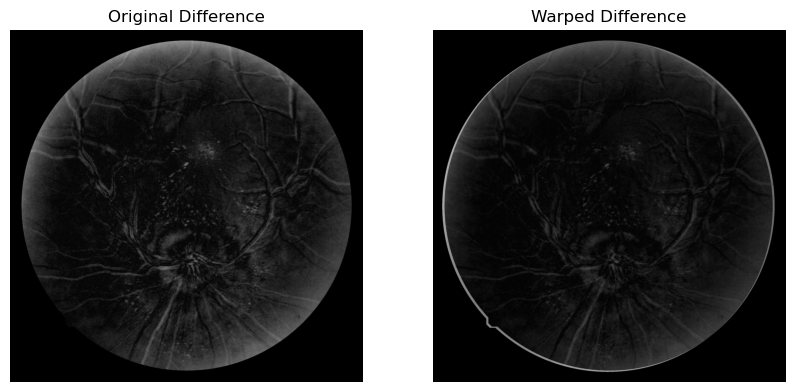

In [82]:
transformation_matrix, registration_dict= airlab_mi_registration(image_name_pair=reference_image_name[0].split('_')[0],
                       fixed_image=img_ref,
                       moved_image=img_test,
                       image_dtype = torch.float32,
                       normalization_type = 'same', # 'same' or 'humansensitivity'
                       metric_num_bins = 32,
                       metric_sigma=1.0,
                       learning_rate = 1e-4,
                       num_iterations = 10,
                       show_plots = True,)

In [83]:
transformation_matrix



tensor([[ 9.9902e-01, -9.7083e-04,  1.1925e-02],
        [-9.8517e-04,  9.9900e-01, -6.5894e-03],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00]], grad_fn=<CopySlices>)

In [84]:
import torch
import sys
from skimage.color import rgb2gray
import SimpleITK as sitk
from airlab.utils.image import Image
import airlab as al
from airlab.registration import PairwiseRegistration

from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image


A01_test = test_images_path / 'Longitudinal_Studies' / 'A01_2.jpg'
A01_reference = reference_images_path / 'Longitudinal_Studies' / 'A01_1.jpg'
img_ref, img_test, test_image_name, reference_image_name = first_batch
image_dtype= torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


img_ref_al = Image(tensor_img_to_sitk(img_ref),image_dtype)
img_test_al = Image(tensor_img_to_sitk(img_test), image_dtype)

al_transformation = al.transformation.pairwise.AffineTransformation( moving_image=img_test_al, opt_cm=False)
al_transformation.init_translation(fixed_image=img_ref_al)

# set the similarity metric:
ami_metric = MI(fixed_image=img_ref_al, moving_image=img_test_al, sigma=0.02, bins=32)
MSE_metric = al.loss.pairwise.MSE(fixed_image=img_ref_al, moving_image=img_test_al)
# set optimizer
al_optimizer = torch.optim.Adam(al_transformation.parameters(), lr=1e-4, amsgrad=True)


# set the registration type: 
registration = PairwiseRegistration()
registration.set_transformation(al_transformation)
registration.set_optimizer(al_optimizer)
registration.set_image_loss([ami_metric])
registration.set_number_of_iterations(10)
registration.start(EarlyStopping=False)




 

0 mi: -0.3854947090148926 
1 mi: -0.3864908218383789 
2 mi: -0.38970518112182617 
3 mi: -0.39238452911376953 
4 mi: -0.391571044921875 
5 mi: -0.3901224136352539 
6 mi: -0.39146852493286133 
7 mi: -0.38890743255615234 
8 mi: -0.38893747329711914 
9 mi: -0.39035654067993164 


In [85]:
al_transformation._compute_transformation_matrix()

tensor([[ 9.9996e-01, -7.2007e-05,  1.4154e-02],
        [ 1.0364e-04,  1.0002e+00, -7.0469e-03]], grad_fn=<SliceBackward0>)

In [86]:
# Comparison before and after registration
warped_image_al = warp_image(img_test_al, al_transformation.get_displacement())
difference_original = sitk.Abs(img_ref_al.itk() - img_test_al.itk())
difference_warped = sitk.Abs(img_ref_al.itk() - warped_image_al.itk())

difference_mean_original = sitk.GetArrayFromImage(difference_original).mean()
difference_mean_warped = sitk.GetArrayFromImage(difference_warped).mean()
print(f"Mean Absolute Difference before registration: {difference_mean_original}")
print(f"Mean Absolute Difference after registration: {difference_mean_warped}")

Mean Absolute Difference before registration: 0.03629998117685318
Mean Absolute Difference after registration: 0.039778757840394974


(np.float64(-0.5), np.float64(2911.5), np.float64(2911.5), np.float64(-0.5))

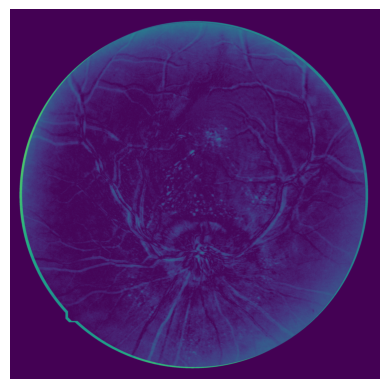

In [87]:
plt.imshow(np.abs(warped_image_al.numpy() - img_ref_al.numpy()))
plt.axis('off')

(np.float64(-0.5), np.float64(2911.5), np.float64(2911.5), np.float64(-0.5))

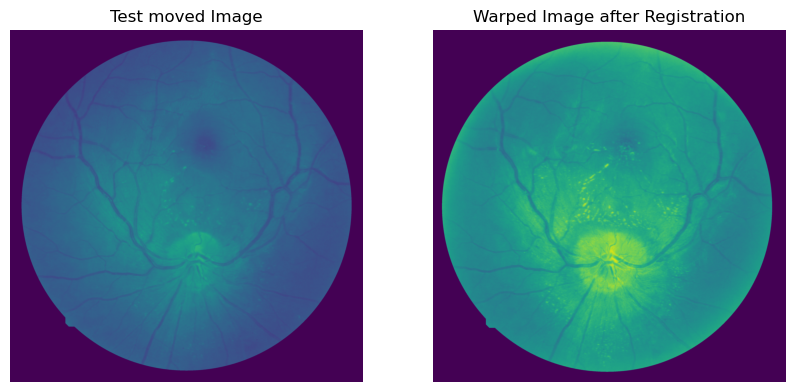

In [88]:
from airlab.transformation.utils import warp_image
# invece di confrontare l'entropia prova a ricostruire l'immagine ottenuta dalla registrazione e la loss calcolata, tramite i mezzi definiti nell'articolo,
# in base alle loss confronta i risultati e definisci le tabelle, dal metodo AMI devi ottenere un modo per calcolare la loss tra le immagini o di avere la trasformazione ottenuta dalla registrazione
warp_image_displacement= al_transformation.get_displacement()
warped_image= warp_image(img_test_al, warp_image_displacement)
warped_image # verifica che sia differente dal tensore originale moving_image e appica la funzione che ci fa 
# vedere la differenza tra le immagini
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('Test moved Image')  
ax[0].imshow(img_ref_al.numpy())
ax[0].axis('off')
ax[1].set_title('Warped Image after Registration')
ax[1].imshow(warped_image.numpy())
ax[1].axis('off')

In [89]:
from airlab.utils.image import Image
import airlab as al
from airlab import PairwiseRegistration
from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image

def clean_and_normalize(img:torch.Tensor
                        )-> torch.Tensor:
    '''
    clean the image from negative values and normalize it between 0 and 1
    '''
    img=torch.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    imin, imax = img.min(), img.max()
    if imax - imin < sys.float_info.epsilon:
        return torch.zeros_like(img)
    else:
        img = (img - imin) / (imax - imin)  
    return img

image_type = torch.float32

img_ref_normalized = clean_and_normalize(img_ref)
img_test_normalized = clean_and_normalize(img_test)

ref_sitk = tensor_img_to_sitk(img_ref_normalized) # prova a usare i metodi di SITK
test_sitk = tensor_img_to_sitk(img_test_normalized)

#importazione delle immagini in formato Image per airlab
ref_al_image = Image(ref_sitk, image_type=image_type)
test_al_image = Image(ref_sitk, image_type=image_type) # prova con la stessa immagine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set the transformation type:
al_transformation = al.transformation.pairwise.AffineTransformation( moving_image=test_al_image, opt_cm=False)
al_transformation.init_translation(fixed_image=ref_al_image)

# set the similarity metric:
ami_metric = MI(fixed_image=ref_al_image, moving_image=test_al_image, bins=64, sigma=0.09)
MSE_metric = al.loss.pairwise.MSE(fixed_image=ref_al_image, moving_image=test_al_image)
# set optimizer
al_optimizer = torch.optim.Adam(al_transformation.parameters(), lr=1e-2, amsgrad=True)


# set the registration type: 
registration = PairwiseRegistration()
registration.set_transformation(al_transformation)
registration.set_optimizer(al_optimizer)
registration.set_image_loss([ami_metric])
registration.set_number_of_iterations(20)
registration.start(EarlyStopping=False)


0 mi: -0.12435722351074219 
1 mi: -0.09519481658935547 
2 mi: -0.09176158905029297 
3 mi: -0.0886392593383789 
4 mi: -0.0881509780883789 
5 mi: -0.08766365051269531 
6 mi: -0.08774757385253906 
7 mi: -0.08771991729736328 
8 mi: -0.08594608306884766 
9 mi: -0.08553695678710938 
10 mi: -0.08388423919677734 
11 mi: -0.0822296142578125 
12 mi: -0.08116436004638672 
13 mi: -0.08037853240966797 
14 mi: -0.07902240753173828 
15 mi: -0.07822990417480469 
16 mi: -0.07781314849853516 
17 mi: -0.07623291015625 
18 mi: -0.07557868957519531 
19 mi: -0.07476806640625 


In [90]:
# Comparison before and after registration with mean absolute difference
warped_image_al = warp_image(img_test_al, al_transformation.get_displacement())
difference_original = sitk.Abs(img_ref_al.itk() - img_test_al.itk())
difference_warped = sitk.Abs(img_ref_al.itk() - warped_image_al.itk())

difference_mean_original = sitk.GetArrayFromImage(difference_original).mean()
difference_mean_warped = sitk.GetArrayFromImage(difference_warped).mean()
print(f"Mean Absolute Difference before registration: {difference_mean_original}")
print(f"Mean Absolute Difference after registration: {difference_mean_warped}")

Mean Absolute Difference before registration: 0.03629998117685318
Mean Absolute Difference after registration: 0.058968350291252136


(np.float64(-0.5), np.float64(2911.5), np.float64(2911.5), np.float64(-0.5))

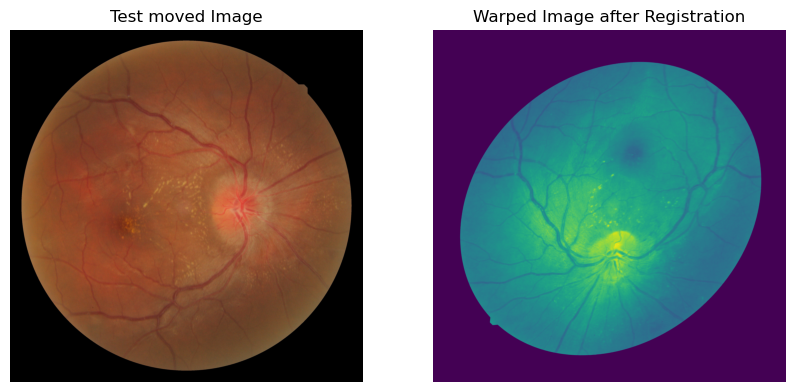

In [91]:
from airlab.transformation.utils import warp_image
# invece di confrontare l'entropia prova a ricostruire l'immagine ottenuta dalla registrazione e la loss calcolata, tramite i mezzi definiti nell'articolo,
# in base alle loss confronta i risultati e definisci le tabelle, dal metodo AMI devi ottenere un modo per calcolare la loss tra le immagini o di avere la trasformazione ottenuta dalla registrazione
warp_image_displacement= al_transformation.get_displacement()
warped_image= warp_image(test_al_image, warp_image_displacement)
warped_image # verifica che sia differente dal tensore originale moving_image e appica la funzione che ci fa 
# vedere la differenza tra le immagini
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('Test moved Image')  
ax[0].imshow(img_test.squeeze().permute(1,2,0).detach().numpy())
ax[0].axis('off')
ax[1].set_title('Warped Image after Registration')
ax[1].imshow(warped_image.numpy())
ax[1].axis('off')

# calcolo della loss e esplicita i risultati della registrazione

In [92]:
esth= torch.randint(0, 10, (3, 4, 5), dtype=torch.float32)
print(esth.shape)
print(esth.mean(dim=0, keepdim=True).shape)

torch.Size([3, 4, 5])
torch.Size([1, 4, 5])


### NORMALIZED MUTUAL INFORMATION ELASTIX

#### Usage of itk elastix from examples

In [93]:
import itk
import numpy as np
import matplotlib.pyplot as plt

def image_generator(x1, x2, y1, y2):
    '''
    Generate a simple synthetic image with a square in the center.
    '''
    image = np.zeros([100, 100], dtype=np.float32)
    image[y1:y2 , x1:x2] = 1.0
    image=itk.image_view_from_array(image)
    return image

def show_images(image_list):
    '''
    Show a list of images using matplotlib.
    '''
    labelled_images= ['fixed', 'moving', 'registered']
    num_images = len(image_list)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    for i, image in enumerate(image_list):
        array_image = itk.array_view_from_image(image)

        axes[i].imshow(array_image, cmap='gray')
        axes[i].set_title(labelled_images[i])
        axes[i].axis('off')
    plt.show()

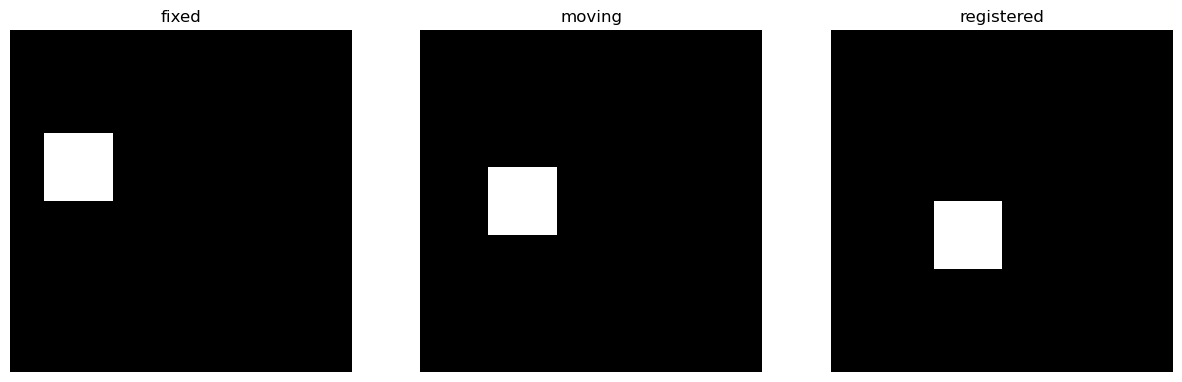

In [94]:
image_list= [image_generator(i, i+20, i+20, i+40) for i in range(10, 40, 10)]
show_images(image_list)
image0 =image_list[0]
image1 =image_list[1]
image2 =image_list[2]

In [95]:
# creating a euler 2d transformation:
traslation = [15.0, -10.0]  # x and y translation
transformation= itk.Euler2DTransform.New()
transformation.SetOffset(traslation) 
transformation.SetAngleInDegrees(15)  
transformation.SetCenter([50.0, 50.0])  # center of rotation

parameter_map ={
    'Direction' : ('1','0','0','1'),
    'Index' : ('0', '0'),
    'Origin' : ('0.0', '0.0'),
    'Size' : ('100', '100'),
    'Spacing' : ('1.0', '1.0'),
    'FinalBSplineInterpolationOrder' : ('0'),
}
transform_parameter_object= itk.ParameterObject.New()
transform_parameter_object.AddParameterMap(parameter_map)
transformix_filter = itk.TransformixFilter.New(image0)
transformix_filter.SetMovingImage(image1)
transformix_filter.SetTransformParameterObject(transform_parameter_object)
transformix_filter.SetTransform(transformation)
transformix_filter.Update()
moved_image = transformix_filter.GetOutput()

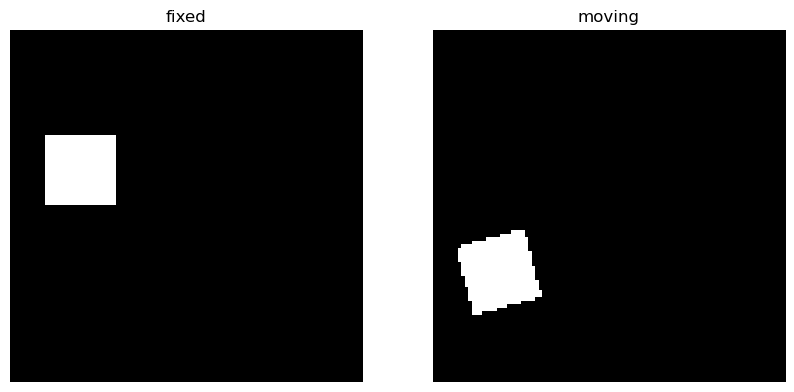

In [96]:
show_images([image0, moved_image])

In [97]:
rigid_parameter_object = itk.ParameterObject.New()
rigid_parameter_map = rigid_parameter_object.GetDefaultParameterMap('rigid')
rigid_parameter_map['FinalBSplineInterpolationOrder'] = ('0')
rigid_parameter_object.AddParameterMap(rigid_parameter_map)

print(rigid_parameter_object)

ParameterObject (0000017FC2679660)
  RTTI typeinfo:   class elastix::ParameterObject
  Reference Count: 1
  Modified Time: 874
  Debug: Off
  Object Name: 
  Observers: 
    none
ParameterMap 0: 
  (AutomaticParameterEstimation "true")
  (AutomaticScalesEstimation "true")
  (CheckNumberOfSamples "true")
  (DefaultPixelValue 0)
  (FinalBSplineInterpolationOrder 0)
  (FixedImagePyramid "FixedSmoothingImagePyramid")
  (ImageSampler "RandomCoordinate")
  (Interpolator "LinearInterpolator")
  (MaximumNumberOfIterations 256)
  (MaximumNumberOfSamplingAttempts 8)
  (Metric "AdvancedMattesMutualInformation")
  (MovingImagePyramid "MovingSmoothingImagePyramid")
  (NewSamplesEveryIteration "true")
  (NumberOfResolutions 4)
  (NumberOfSamplesForExactGradient 4096)
  (NumberOfSpatialSamples 2048)
  (Optimizer "AdaptiveStochasticGradientDescent")
  (Registration "MultiResolutionRegistration")
  (ResampleInterpolator "FinalBSplineInterpolator")
  (Resampler "DefaultResampler")
  (ResultImageFormat "

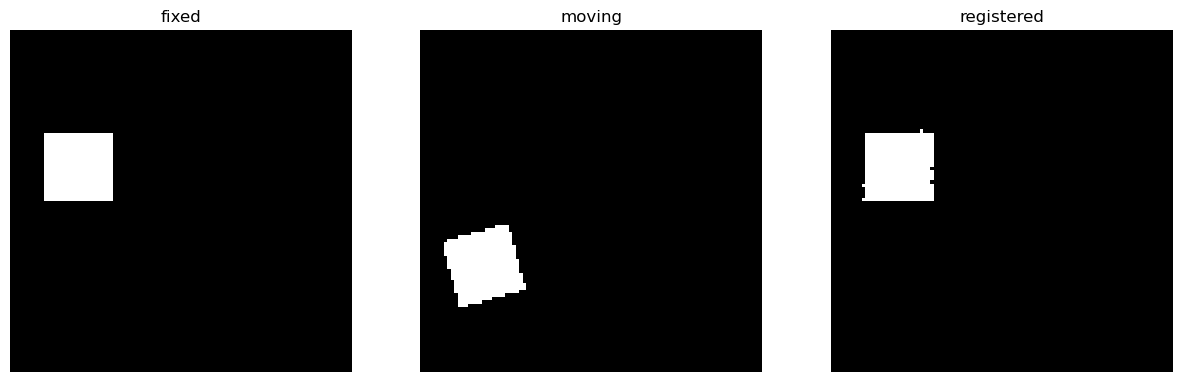

In [98]:
unconstrained_result_image, result_transform_parameters = itk.elastix_registration_method(
    image0, moved_image,
    parameter_object=rigid_parameter_object,
    log_to_console=False)
show_images([image0, moved_image, unconstrained_result_image])

In [99]:
type(img_ref), img_test.shape, reference_images_path, fire_images_path,reference_files[1], test_files[1]

(torch.Tensor,
 torch.Size([1, 3, 2912, 2912]),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference'),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images'),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A02_1.jpg'),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Test/Longitudinal_Studies/A02_2.jpg'))

In [100]:
def extract_image_name(image_path: Path
                             )-> str:
    '''
    Extract the image name from the image path without extension.
    '''
    return image_path.stem

#plt.imshow(np.array(itk.array_view_from_image(fixed_image)))
def rescaling_image(img):
    '''
    Rescale the image to the range [0, 1] 
    '''
    rescaler = itk.RescaleIntensityImageFilter.New(img)
    rescaler.SetOutputMinimum(0.0)
    rescaler.SetOutputMaximum(1.0)
    rescaler.Update()
    rescaled_img = rescaler.GetOutput()
    return rescaled_img
#plt.imshow(np.array(itk.array_view_from_image(rescaling_image(fixed_image))))
def elastix_show_difference_image(fixed_image,
                                moved_image,
                                registered_image
                               )-> None:
    '''
    Show the difference images between fixed and moving, and fixed and registered images.
    '''# prima normalizza poi differenza
    fixed_normalized = rescaling_image(fixed_image)
    moved_normalized = rescaling_image(moved_image)
    registered_normalized = rescaling_image(registered_image)
    original_difference = np.array(itk.array_view_from_image(fixed_normalized) - np.array(itk.array_view_from_image(moved_normalized)))
    registered_difference = np.array(itk.array_view_from_image(fixed_normalized) - np.array(itk.array_view_from_image(registered_normalized)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.figsize=[100,100]
    axes[0].imshow(original_difference, cmap='gray')
    axes[0].set_title('Prior Registration', fontsize=10, loc='left')
    axes[0].axis('off')
    axes[0].set_title(f'RMSE: {np.sqrt((original_difference**2).mean()):.4f}', fontsize=10, loc='right')
    axes[1].imshow(registered_difference, cmap='gray')
    axes[1].set_title('After Registration', fontsize=10, loc='left')
    axes[1].axis('off')
    axes[1].set_title(f'RMSE: {np.sqrt((registered_difference**2).mean()):.4f}', fontsize=10, loc='right')
    fig.get_label()
    plt.savefig(imagedir_save_path / 'Difference_Elastix.png')
    plt.show()

    return None




In [101]:
import itk
# definisci una funzione per fare questo a partire da reference_files e test_files e 
# impostare alcuni dati, solo numerici; imposta un timer per controllare quanto tempo 
#ci mette la registrazione
fixed_image = itk.imread(reference_files[0], itk.F)
moved_image = itk.imread(test_files[0], itk.F)

transformation_parameters = itk.ParameterObject.New() # set the pparameter object
affine_params_map = transformation_parameters.GetDefaultParameterMap('affine') # set the parameter for affine transformation
affine_params_map['metric'] = ['NormalizedMutualInformation']
affine_params_map['NumberOfHistogramBins'] = ['32']
affine_params_map['NumberOfResolutions'] = ['3']
affine_params_map['MaximumNumberOfIterations'] = ['5000']
transformation_parameters.SetParameterMap(affine_params_map)
final_image, registration_parameters=  itk.elastix_registration_method(
    fixed_image=fixed_image,
    moving_image=moved_image,
    parameter_object=transformation_parameters,
    log_to_console=True)
#transform_parameter_object.SetParameterMap(affine_params_map)

# Save results: 
image_name = reference_files[0].stem.split('_')[0]
itk.imwrite(final_image, str(elastix_saving_folder / f'{image_name}.nii.gz'))

# chiama funzione





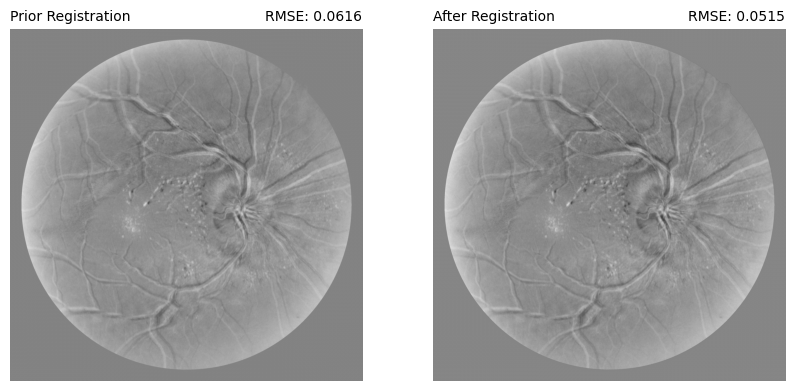

In [102]:
elastix_show_difference_image(fixed_image=fixed_image,
                              moved_image=moved_image, 
                              registered_image=final_image)


In [103]:
# elastix
#0. importations
import SimpleITK as sitk
import itk
import torch
import numpy as np
import matplotlib.pyplot as plt

#1. get iimage from path or tensor from dataset:
def elastix_registration(reference_image_path : Path,
                        test_image_path : Path,
                        histogram_bins : int = 32,
                        num_resolutions : int = 3,
                        max_iterations : int = 5000,
                        )-> tuple:
    '''
    the registration of two images using elastix via itk 
    Parameters
    ----------
    reference_image_path : Path
        The path to the reference image.
    test_image_path : Path
        The path to the test image.
    histogram_bins : int
        Number of histogram bins for the mutual information metric.
    num_resolutions : int
        Number of pyramid's steps for the registration.
    max_iterations : int
        Maximum number of iterations for the registration.
    
    Returns
    -------
    tuple
        The registered image and the registration parameters.
    '''
    fixed_image = itk.imread(reference_image_path, itk.F)
    moved_image = itk.imread(test_image_path, itk.F)

    transformation_parameters = itk.ParameterObject.New() # set the pparameter object
    affine_params_map = transformation_parameters.GetDefaultParameterMap('affine') # set the parameter for affine transformation
    affine_params_map['metric'] = ['NormalizedMutualInformation']
    affine_params_map['NumberOfHistogramBins'] = [f'{histogram_bins}']
    affine_params_map['NumberOfResolutions'] = [f'{num_resolutions}']
    affine_params_map['MaximumNumberOfIterations'] = [f'{max_iterations}']
    transformation_parameters.SetParameterMap(affine_params_map)
    final_image, registration_parameters=  itk.elastix_registration_method(
        fixed_image=fixed_image,
        moving_image=moved_image,
        parameter_object=transformation_parameters,
        log_to_console=True) 
    return (final_image, registration_parameters)
#2. preprocess images if necessary

#3. prepare registration process
#sitk.



### NAED for image control point

In [271]:
from typing import Literal
def naed_evaluation(image_couple_name: str,
                    affine_matrix: np.ndarray | torch.Tensor, 
                    image_normalization :  Literal['diagonal' , 'coords_norm'] = 'coords_norm',
                    control_points_path: Path = CONTROL_POINTS_FOLDER,
                    image_dimensions: tuple | Path = (2912, 2912) ,
                    )-> float:
    '''
    Evaluate the registration using Normalized Average Euclidean Distance (NAED) metric.
    Parameters
    ----------
    image_couple_name : str
        The name of the image couple to get the control points file from the list. It has to be in the format 'A01', 'P19', 'S20', etc.
    control_points_file : Path
        The path to the control points coordinates.
    affine_matrix : np.ndarray | torch.Tensor
        The affine transformation matrix get by image registration algoritm it has to be in the complete form : | A t |
                                                                                                                | 0 a |
    image_dimensions : tuple | Path
        The dimensions of the images or the path to the image to get the dimensions to normalize.
    '''
    h,w = image_dimensions
    #1. get the control points for the image couple
    test_points_list, reference_points_list = get_coords(image_name=image_couple_name)
    test_points = np.array(test_points_list)  # shape (N, D)  D = 2 
    reference_points = np.array(reference_points_list)  # shape (N, D)

    assert test_points.shape == reference_points.shape , "Test and reference points must have the same shape"

    #2. control of affine matrix? for 2/3D or affine type? NOTE for the moment it has just to be in a quadratic form NxN
    if isinstance(affine_matrix, torch.Tensor):
        affine_matrix = affine_matrix.detach().cpu().numpy()
    n, m = affine_matrix.shape
    if n != m:
        raise ValueError(f'The affine matrix must be square, got {n}x{m}')
    
    if n == 4:
        total_distance = np.nan # NOTE the 3D case has yet to be treated
        return total_distance
    
    elif n == 3:
        #3. for each list of coords: apply the matrix -> get the Euclidean distance
        total_distance = 0.0
        assert test_points.shape[-1] == 2, "Test points must be 2D coordinates"
        ones_column = np.ones((test_points.shape[0], 1))
        homogeneous_test_points = np.hstack((test_points, ones_column))  # shape (N, 3
        homogeneous_warped_points = np.rint(homogeneous_test_points @ affine_matrix.T).astype(np.int32)  # shape (N, 3), already interpolated, using round/nearest neighbor
        
        incongruencies = [w for w in homogeneous_warped_points[:, 2] if w == 0]
        if len(incongruencies) > 0:
            total_distance = np.nan #raise ValueError("There are some incongruencies in this transformation, some points have w=0") #FIXME return NaN o gestisci in altro modo
            return total_distance
        
        else: 
            warped_points = np.rint([[x_w/w, y_w/w] for (x_w, y_w, w) in homogeneous_warped_points]).astype(np.int32)  # shape (N, 2)
            total_distance += np.linalg.norm(warped_points - reference_points, axis=1).mean()

    #4. normalize the NAED value
    if image_normalization == 'diagonal':
        #4.1 get the NAED value using image diagonal to normalize
        ratio = np.sqrt(h**2 + w**2)
    elif image_normalization == 'coords_norm':
        #4.2 get the NAED value using the norm of the image dimensions to normalize
        ratio = h
        
    #5. return NAED value in float
    naed_value = total_distance / ratio
    
    return naed_value
    


In [272]:
test_points, ref_points = get_coords('A01')
test_points = np.array(test_points)
ref_points = np.array(ref_points)
ones = np.ones((test_points.shape[0], 1))

test_homogeneous = np.hstack((test_points, ones))  # shape (N, D+1)
ref_homogeneous = np.hstack((ref_points, ones))

matrix_es =transformation_matrix.detach().cpu().numpy()
homogeneous_warped_cords = np.rint(test_homogeneous @ matrix_es.T).astype(np.int32)
warped_coords = np.rint([[x/w, y/w] for (x, y, w) in homogeneous_warped_cords]).astype(np.int32)
total_distance = np.linalg.norm(warped_coords- ref_points.astype(np.int32), axis=1).mean()
norm_distance = total_distance / 2912
print(f'total distance : {total_distance};\nnormalized distance with norm coords: {total_distance / 2912};\nnorm distance over diagonal: {total_distance/ (np.sqrt(2)*2912)}')

total distance : 64.71563614756613;
normalized distance with norm coords: 0.022223776149576283;
norm distance over diagonal: 0.015714582818937246


In [273]:
naed_calculated_coords = naed_evaluation(image_couple_name='A01',
                                  affine_matrix=matrix_es,
                                    image_normalization='coords_norm',
                                    image_dimensions=(2912, 2912))

naed_calculated_diagonal = naed_evaluation(image_couple_name='A01',
                                  affine_matrix=matrix_es,
                                    image_normalization='diagonal',
                                    image_dimensions=(2912, 2912))  
print(f'NAED calculated with coords norm: {naed_calculated_coords};\nNAED calculated with diagonal norm: {naed_calculated_diagonal}')

NAED calculated with coords norm: 0.022223776149576283;
NAED calculated with diagonal norm: 0.01571458281893725


In [244]:
np.linalg.norm(warped_coords- ref_points.astype(np.int32), axis=1), warped_coords

(array([75.00666637, 52.20153254, 63.        , 94.33981132, 89.19641248,
        98.23441352, 64.62197769, 41.23105626, 50.21951812, 19.10497317]),
 array([[ 387,  821],
        [ 355, 1847],
        [1149, 2483],
        [1841,  398],
        [2354, 1996],
        [2552, 1194],
        [1946, 1191],
        [ 668, 1190],
        [1941, 1457],
        [1325, 1781]], dtype=int32))

In [249]:
aed = [np.sqrt((warped[0]-ref[0])**2+(warped[1]-ref[1])**2) for warped, ref in zip(warped_coords, ref_points.astype(np.int32))]
np.array(aed).mean()
    

np.float64(64.71563614756613)

In [106]:
import numpy as np
import torch

def create_random_homogeneous_matrix(dim : int) -> torch.Tensor:
    '''
    It create a random homogeneous matrix for 2D or 3D transformations.
    '''
    if dim not in [2, 3]:
        raise ValueError("Dimension must be 2 or 3")
    matrix_size = dim + 1
    while True:
        random_matrix = torch.randn((matrix_size, matrix_size), dtype=torch.float32)
        random_matrix[-1, -1] = 1.0
        if torch.linalg.cond(random_matrix)<1e6 or abs(random_matrix.det()) > 1e-6:
            return random_matrix
        
def homo_or_affine_dim_matrix(matrix_to_be_tested : torch.Tensor):
    '''give a explanation of what matrix is'''
    pass


### Scacchiera per informazione minima

divide by zero encountered in log


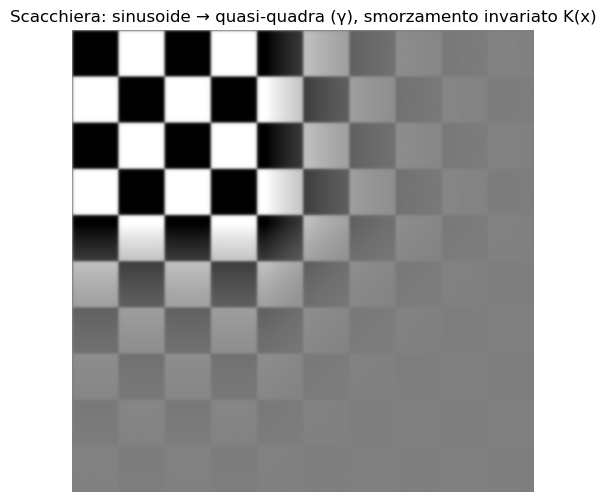

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parametri principali
# -----------------------
N = 1000           # dimensione array (NxN)
T = 200            # periodo spaziale (px) delle celle
A = 0.5            # ampiezza base (come nel tuo modello)
y_offset = 0.5     # offset per mappare in [0,1] via formula finale
gamma = 10.0       # "squareness": >5 inizia a sembrare una quadra, aumenta per bordi più netti

# -----------------------
# Smorzamento: K_smorz(x) = 100 * exp(-k*x)
# vincolo: K(900) ≈ 0.5  => k = ln(200)/900  (invariato)
# -----------------------
k_min = np.log(100.0) / 600.0

x = np.arange(N)
k_exp= np.log(100.0*x)/800.0*N

K_exp = np.clip(50.0 * np.exp(-k_min*x), k_min, 100)  # NON modificato
K_lin = 1.0 - 0.5*(x)/N
# Traduzione in CONTRASTO per restare in [-1,1] senza toccare K:
# m(x) = clip(A * K(x), 0, 1)
mx = np.clip(A * K_exp, 0.0, 1.0)
my = mx.copy()  # simmetria

# -----------------------
# Onde "quasi quadre" lungo X e Y (periodo T)
# -----------------------
phase_x = 2.0 * np.pi * x / T
sqx = np.tanh(gamma * np.sin(phase_x))   # [-1, 1]
sqy = sqx.copy()                         # simmetria

# Applica lo smorzamento come CONTRASTO (non cambia K)
Sx = mx * sqx            # in [-mx, mx]
Sy = my * sqy            # in [-my, my]

# -----------------------
# Combinazione a scacchiera (prodotto, non media!)
# V in [0,1]; se mx,my -> 0, V -> 0.5 (grigio)
# -----------------------
V = 0.5 * (1.0 - np.outer(Sy, Sx))  # Sy[:,None] * Sx[None,:]

# -----------------------
# Visualizzazione
# -----------------------
plt.figure(figsize=(6,6))
plt.imshow(V, cmap='gray', vmin=0.0, vmax=1.0)
plt.title('Scacchiera: sinusoide → quasi-quadra (γ), smorzamento invariato K(x)')
plt.axis('off')
plt.show()



### Collect results of various methods:
-time of registration

-name of image pair

-registration matrix

COLLECT THE RESULTS IN A DATAFRAME


In [108]:
'''for i in Path(this_file_path.parent / 'Results'/ 'CSVRes').iterdir():
    print(i)'''
RESULT_PATH

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Results')

In [109]:
import pandas as pd
from pathlib import Path

class Registration_Data_Collector:
    '''
    A class to collect and store registration data on the entire dataset.
    '''
    def __init__(self):
        self.collection = {}

    def add_registration_data(self,
                              image_pair_name: str, 
                              registration_data: dict,
                              registration_name: str | None = None):
        '''
        Collect registration information for a specific image pair and registration method.'''
        
        if image_pair_name not in self.collection:
            self.collection[image_pair_name] = {}
        for key, value in registration_data.items():
            self.collection[image_pair_name][key] = value
        
        if registration_name:
            self.registration_name = registration_name

    @property
    def get_dataframe(self) -> pd.DataFrame:
        '''
        Convert the collected registration data into a pandas DataFrame.
        '''
        df = pd.DataFrame.from_dict(self.collection, orient="index")
        df.index.name = "image_pair_name"
        return df.reset_index().set_index('image_pair_name')
    
    def save_data(self, 
                  filepath :str | Path = Path(RESULT_PATH / 'CSVResults'),
                  fmt:str | None = None):
        '''Saving the collected data to a file in the specified format (csv or json or excel).'''
        if self.registration_name != None:
            path = Path(filepath / f'{self.registration_name}.{fmt if fmt else "csv"}')
            # NOTE add condition for not getting saving name?
        df = self.get_dataframe
        if fmt is None:
            fmt = path.suffix.lstrip('.').lower()
        else:
            fmt = 'csv'
        
        fmt=fmt.lower()

        if fmt=='csv':
            df.to_csv(path)
        elif fmt=='json':
            df.to_json(path, orient="index")
        elif fmt in ('excel', 'xls', 'xlsx'):
            if fmt == '':
                path = path.with_suffix('.xlsx')
            df.to_excel(path)
        else:
            raise ValueError(f"Unsupported format: {fmt}. Supported formats are 'csv', 'json', 'excel'.")
        return None

### DA FARE : RIFORMULA LE LOSS CONSIDERANDOLE COME DELLE NETWORK IN MODO CHE I PESI DELLE RETI VENGANO AGGIORNATI A OGNI ROUND

#### Da FARE : trovare il best lr per i parametri di mine_net e homography_net, 

#### FATTO : creare un oggetto risultati in cui sono inclusi per ogni step un oggetto Collect_Results
1. la lista delle matrici omografiche PER OGNI LIVELLO
2. la lista delle loss PER OGNI LIVELLO ( in base al valore della loss per la valutazione? o la mi_loss)
3. il learning rate per ottenere tale oggetto ( da creare e salvare prima dello step dell'optimizer e dello scheduler)
4. l'alternativa al punto 2.

In [110]:
import pandas as pd
def filter_keys(d,
                excluded_keys: list[str]
                ) -> dict:
    '''
    filter the dictionary to exclude the keys in excluded_keys
    Parameters
    ----------
    d : dict
        the dictionary to filter
    excluded_keys : list[str]
        the keys to exclude from the dictionary
    Returns
    -------
    dict
        the filtered dictionary, the original w/o the excluded keys
    '''
    if isinstance(d, dict):
        return {k: filter_keys(v,excluded_keys) for k, v in d.items() if k not in excluded_keys}
    return d

class  Collect_Results(): # ? or do a dataframe?
    def __init__(self, image_pair: str):
        self.name = image_pair
        self.images_results = {}
        self.images_results[f'{self.name}'] = {}

    def add_data(self, 
                iteration: int,
                loss: list[float] = [], 
                mi_loss: list[float] = [],
                homography_matrix: torch.Tensor | list[torch.Tensor] = None,
                lr: float = np.nan,
                ): 
        '''
        add data to the dictionary:
        Parameters
        ----------
        iteration : int
            the iteration of the training

        loss : list[float], optional
            the loss of the training, by default []

        mi_loss : list[float], optional
            the mutual information loss of the training, by default []

        homography_matrix : torch.Tensor | list[torch.Tensor], optional
            the homography matrix of the training, by default []

        lr : float, optional
            the learning rate of the training, by default np.NaN

        '''
        self.images_results[f'{self.name}'][f'iteration - {iteration}'] = {}
        if not loss:
            loss = np.nan
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['loss'] = loss
        if not mi_loss:
            mi_loss = np.nan
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['MI'] = mi_loss
        if homography_matrix == []:
            pass
        else:
            self.images_results[f'{self.name}'][f'iteration - {iteration}']['homography_matrix'] = homography_matrix
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['lr'] = lr

    def get_data(self, 
                type : str,
                datatype: str = ''
                )-> list | pd.DataFrame:
        '''
        get the data from dictionary in a certain format
        Parameters
        ----------
        type : str
            the type of data to get from the dictionary: 
                'list' to get a specified datatype in list format, #NOTE it works also for the homomatrices
                'df' to get the dollected results in a dataframe format
        
        datatype : str
            the datatype to get from the dictionary:
                'loss' to get the loss of the training
                'mi' to get the mutual information loss of the training
                'homography_matrix' to get the homography matrix of the training
                'lr' to get the learning rate of the training
        '''
        if not self.images_results[f'{self.name}'].keys(): # in case the dictionary is empty
            raise ValueError(f'No data available for {self.name}')
        avaiable_data = [x for x in self.images_results[f'{self.name}'][f'iteration - 0'].keys()]
        if type == 'list': # to retrieve a specific datatype
            if not datatype in avaiable_data: # if the requested datatype is not in the dictionary keys
                raise ValueError(f'Invalid datatype {datatype} for {self.name},\nselect from {avaiable_data}')
            else:
                data = [] 
                for iteration in self.images_results[f'{self.name}'].keys():
                    data.append(self.images_results[f'{self.name}'][iteration][datatype])
                return data
        elif type == 'df': # to retrieve all the data in a dataframe format
            df_wo_homomatrices = filter_keys(self.images_results[f'{self.name}'], excluded_keys=['homography_matrix'])
            return pd.DataFrame(data=df_wo_homomatrices).T
        
    
    #     restiruisci un df o una lista dei dati per ottenere una più facile visualizzazione
    

    

In [111]:
import numpy as np

# Definire la dimensione dei tensori
tensor_shape = (2, 2)

# Creare una lista di tensori
tensor_list = []

for i in range(5):  # Creare 5 tensori
    tensor = np.random.rand(*tensor_shape)  # Tensore con valori casuali
    tensor_list.append(tensor)

tensor_list

[array([[0.99492634, 0.27314341],
        [0.96457144, 0.12095464]]),
 array([[0.05597809, 0.75998511],
        [0.31786732, 0.65504564]]),
 array([[0.76019947, 0.89254607],
        [0.09832501, 0.62406799]]),
 array([[0.76534983, 0.76819688],
        [0.50979515, 0.36044841]]),
 array([[0.63430771, 0.87673298],
        [0.95886596, 0.76515973]])]

In [112]:
import pandas as pd
a01_res = Collect_Results('A01')
a_void = Collect_Results('A_void')
for i in range(5):
    a01_res.add_data(iteration=i, lr=0.001*(i+1), loss=[0.1*(i+1)], homography_matrix=torch.Tensor(tensor_list[i]))


In [113]:

dataframe_a01 = a01_res.get_data(type='df')
dataframe_a01

,loss,MI,lr
iteration - 0,[0.1],NaN,0.001
iteration - 1,[0.2],NaN,0.002
iteration - 2,[0.30000000000000004],NaN,0.003
iteration - 3,[0.4],NaN,0.004
iteration - 4,[0.5],NaN,0.005


In [114]:
homo_list = a01_res.get_data(type='list', datatype='homography_matrix')
homo_list

[tensor([[0.9949, 0.2731],
         [0.9646, 0.1210]]),
 tensor([[0.0560, 0.7600],
         [0.3179, 0.6550]]),
 tensor([[0.7602, 0.8925],
         [0.0983, 0.6241]]),
 tensor([[0.7653, 0.7682],
         [0.5098, 0.3604]]),
 tensor([[0.6343, 0.8767],
         [0.9589, 0.7652]])]

In [115]:
diz, diz_info, diz_iteration = {}, {}, {}
for i in range(3):
    diz_info[f'iteration{i}'] = {}
    diz_info[f'iteration{i}']['loss']= 1.34 + i
    diz_info[f'iteration{i}']['mi_loss'] = 0.23 + i
    diz_info[f'iteration{i}']['homography_matrix'] = torch.eye(i+1)
    diz_info[f'iteration{i}']['lr'] = 0.001 * (i + 1) 


diz['A01'] = diz_info
image_pair = 'A01'
iteration_of_interest = 1
data_to_retrieve ='lr'
diz[image_pair][f'iteration{iteration_of_interest}'][data_to_retrieve]

0.002

successivamente:
1. provare a calcolare la mi con altri metodi di approssimazione numerica o probabilistici
2. calcolare l'approssimazione con il runge-kutta e considerare le immagini come flussi dinamici


#### DA FARE: plottare i risultati o riprendere il modo per analizzare la rete ottenuta durante l'allenamento

In [116]:
def plot_graph(values: list[float],
              title: str = 'Loss',
              xlabel: str = 'Iteration',
              ylabel: str = 'Loss',
              save_path: Path = None ,
              show: bool = True,
              ) -> None:
    '''
    plot the loss values over the epochs
    Parameters
    ----------
    loss_values : list[float]
        the list of loss values to be plotted
    title : str
        the title of the plot
    xlabel : str
        the label of x axis
    ylabel : str
        the label of y axis
    save_path : Path
        the path to save the plot
    show : bool
        whether to show the plot or not

    Returns
    -------
    None
    '''
    values = [x*x for x in values]
    plt.plot(values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if save_path:
        save_path = save_path / f'{title}.png'
        plt.savefig(save_path)
    if show:
        plt.show()
    
    return None

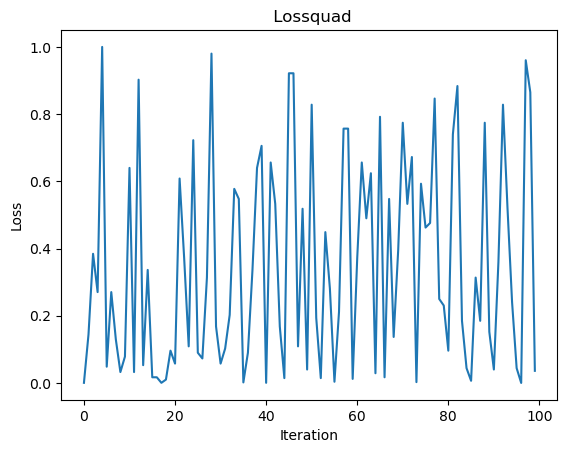

In [117]:
random_loss_values = [round(x, 2) for x in np.random.rand(100)]
plot_graph(random_loss_values, title=' Lossquad', xlabel='Iteration', ylabel='Loss', show=True)

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation(tensor_list, animation_name='animation.gif'):
    # Ensure tensor_list is not empty
    if not tensor_list:
        raise ValueError("The tensor list is empty.")
    
    # Get the dimensions of the tensors
    _, N, M = tensor_list[0].shape
    
    # Create a figure and axis for the animation
    fig, ax = plt.subplots()
    
    # Initialize the image with the first tensor
    im = ax.imshow(tensor_list[0].transpose(1, 2, 0), animated=True)
    
    # Update function for the animation
    def update(frame):
        im.set_array(frame.transpose(1, 2, 0))
        return im,
    
    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=tensor_list, blit=True)
    
    # Save the animation as a GIF file
    save_path = this_file_path.parent / 'Results' / animation_name
    ani.save(save_path, writer='pillow')
    
    plt.close(fig)
    print(f"Animation saved as {animation_name}")

# Example usage:
# Create a list of random tensors with dimensions [3, 100, 100]
tensor_list = [np.random.rand(3, 100, 100) for _ in range(10)]

# Create and save the animation
create_animation(tensor_list)


Animation saved as animation.gif


In [119]:
a = torch.Tensor(np.arange(0, 10 , 1))
b = torch.Tensor(np.arange(10, 20 , 1))
c = torch.stack([a, b], 1)
d = torch.cat([a, b], 0)
c.shape, c, d.shape, d

(torch.Size([10, 2]),
 tensor([[ 0., 10.],
         [ 1., 11.],
         [ 2., 12.],
         [ 3., 13.],
         [ 4., 14.],
         [ 5., 15.],
         [ 6., 16.],
         [ 7., 17.],
         [ 8., 18.],
         [ 9., 19.]]),
 torch.Size([20]),
 tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
         14., 15., 16., 17., 18., 19.]))

In [120]:
a, b , c = 0 , 2 , 1
a != b != c

True

In [121]:
# Create a train model funciton for a specified image couple
def train_model (model : MINE,
                homography_net : HomographyNet,
                optimizer : optim.Optimizer,
                fixed_pyramid : tuple[np.ndarray],
                moving_pyramid : tuple[np.ndarray],
                loss :nn.Module,
                n_epochs : int = 1,
                n_iterations : int = 50,
                device : str = None , # or 'cuda' or 'cpu'
                 ) -> None :
    '''
    the way to train a model through the parameter optimization of the homography net

    Parameters:
    -----------
        model (MINE): the net to calculate the mutual information parameter for optimize the model

        homography_net (HomographyNet): the net to calculate the homography matrix for the image couple
        
        optimizer (optim.Optimizer): the algorithm step to optimize the parameters of the homography net
        
        fixed_pyramid (tuple[np.ndarray]): the pyramid of the fixed image
        
        moving_pyramid (tuple[np.ndarray]): the pyramid of the moving image
        
        loss (nn.Module): the loss function to calculate the loss between the two images
        
        n_epochs (int): the number of epochs to train the model
        
        n_iterations (int): the number of iterations to train the model
        
        device (str): the device to use for the training

    '''
    pass

In [122]:
# per il training usa due diverse loss, la prima fa tutto all'interno del modello... l'altra fa in modo di avere un modello che trasforma l'immagine e successivamente calcola la loss tramite la mine net

#### PROVA LR_SCHEDULER con ionosphere data.csv


In [123]:
import pandas as pd



In [124]:
dati = Path.cwd() / 'ionosphere.data'
dati.exists()

True

In [125]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import requests

file_dati = Path.cwd() / 'ionosphere.data'
if not file_dati.exists():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'

    # Scaricare il file .data


    # Scaricare il file .data
    response = requests.get(url)
    data = response.text

    # Salvare il contenuto del file .data in un file locale
    with open('ionosphere.data', 'w') as file:
        file.write(data)

# Leggere il file .data con pandas
column_names = [f'Attribute{i}' for i in range(1, 35)] + ['Class']
dataframe = pd.read_csv('ionosphere.data', header=None, names=column_names)

# Salvare il DataFrame in un file CSV
dataframe.to_csv('ionosphere.csv', index=False)

# load dataset, split into input (X) and output (y) variables

dataset = dataframe.values
X = dataset[:,0:34].astype(float)
y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

# convert into PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# train-test split for evaluation of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# create model
model = nn.Sequential(
    nn.Linear(34, 34),
    nn.ReLU(),
    nn.Linear(34, 1),
    nn.Sigmoid()
)
#Prepare list of values to track off
loss_list, lr_list, epoch_loss = [], [], []

# define the lambda function for the lr lr=lr_0/(alpha + beta*epoch)
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
        
# Train the model
n_epochs = 50
batch_size = 24
batch_start = torch.arange(0, len(X_train), batch_size)
lr = 0.1
count = 0
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=lr)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)
model.train()
for epoch in range(n_epochs):
    
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss_list.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1
    before_lr = optimizer.param_groups[0]["lr"]
    lr_list.append(before_lr)
    
    scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: SGD lr %.4f -> %.4f" % (epoch, before_lr, after_lr))

# evaluate accuracy after training
model.eval()
y_pred = model(X_test)
acc = (y_pred.round() == y_test).float().mean()
acc = float(acc)
print("Model accuracy: %.2f%%" % (acc*100))

Epoch 0: SGD lr 0.1000 -> 0.0909
Epoch 1: SGD lr 0.0909 -> 0.0833
Epoch 2: SGD lr 0.0833 -> 0.0769
Epoch 3: SGD lr 0.0769 -> 0.0714
Epoch 4: SGD lr 0.0714 -> 0.0667
Epoch 5: SGD lr 0.0667 -> 0.0625
Epoch 6: SGD lr 0.0625 -> 0.0588
Epoch 7: SGD lr 0.0588 -> 0.0556
Epoch 8: SGD lr 0.0556 -> 0.0526
Epoch 9: SGD lr 0.0526 -> 0.0500
Epoch 10: SGD lr 0.0500 -> 0.0476
Epoch 11: SGD lr 0.0476 -> 0.0455
Epoch 12: SGD lr 0.0455 -> 0.0435
Epoch 13: SGD lr 0.0435 -> 0.0417
Epoch 14: SGD lr 0.0417 -> 0.0400
Epoch 15: SGD lr 0.0400 -> 0.0385
Epoch 16: SGD lr 0.0385 -> 0.0370
Epoch 17: SGD lr 0.0370 -> 0.0357
Epoch 18: SGD lr 0.0357 -> 0.0345
Epoch 19: SGD lr 0.0345 -> 0.0333
Epoch 20: SGD lr 0.0333 -> 0.0323
Epoch 21: SGD lr 0.0323 -> 0.0312
Epoch 22: SGD lr 0.0312 -> 0.0303
Epoch 23: SGD lr 0.0303 -> 0.0294
Epoch 24: SGD lr 0.0294 -> 0.0286
Epoch 25: SGD lr 0.0286 -> 0.0278
Epoch 26: SGD lr 0.0278 -> 0.0270
Epoch 27: SGD lr 0.0270 -> 0.0263
Epoch 28: SGD lr 0.0263 -> 0.0256
Epoch 29: SGD lr 0.0256 

In [126]:
lr_list

[0.1,
 0.09090909090909091,
 0.08333333333333334,
 0.07692307692307693,
 0.07142857142857144,
 0.06666666666666667,
 0.0625,
 0.0588235294117647,
 0.05555555555555556,
 0.05263157894736842,
 0.05,
 0.047619047619047616,
 0.045454545454545456,
 0.04347826086956522,
 0.041666666666666664,
 0.04000000000000001,
 0.038461538461538464,
 0.037037037037037035,
 0.03571428571428572,
 0.034482758620689655,
 0.03333333333333333,
 0.03225806451612903,
 0.03125,
 0.0303030303030303,
 0.02941176470588235,
 0.02857142857142857,
 0.02777777777777778,
 0.027027027027027025,
 0.02631578947368421,
 0.02564102564102564,
 0.025,
 0.02439024390243903,
 0.023809523809523808,
 0.023255813953488372,
 0.022727272727272728,
 0.022222222222222223,
 0.02173913043478261,
 0.021276595744680854,
 0.020833333333333332,
 0.02040816326530612,
 0.020000000000000004,
 0.0196078431372549,
 0.019230769230769232,
 0.01886792452830189,
 0.018518518518518517,
 0.018181818181818184,
 0.017857142857142856,
 0.017543859649122806

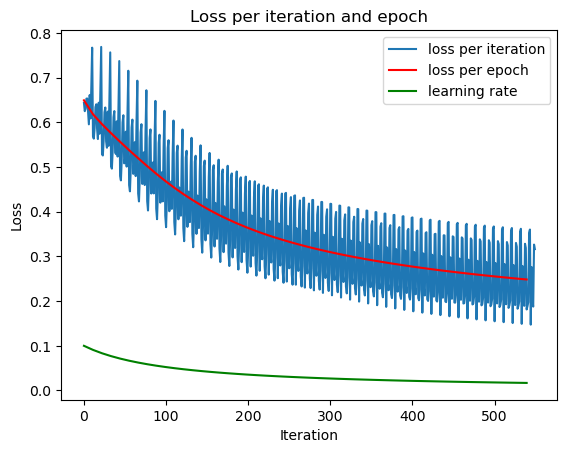

In [127]:

iterations = [i for i in range(len(loss_list))]
epoch_loss = [sum(loss_list[i:i+len(batch_start)])/len(batch_start) for i in range(0, len(loss_list), len(batch_start))]
epochs_iteration = [i for i in range(0, len(loss_list), 11)]
plt.plot(iterations, loss_list, label='loss per iteration')
plt.plot(epochs_iteration, epoch_loss, label='loss per epoch', c='red')
plt.plot(epochs_iteration, lr_list, label='learning rate', c='green')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss per iteration and epoch')
plt.legend()
plt.savefig(Path.cwd().parent / 'Results' / 'SGD_lambda_lr_1.0_loss_per_iteration_and_epoch.png')


In [128]:
optimizer.param_groups[0].keys()


dict_keys(['params', 'lr', 'momentum', 'dampening', 'weight_decay', 'nesterov', 'maximize', 'foreach', 'differentiable', 'fused', 'initial_lr'])

In [129]:
optimizer.param_groups[0]['lambda_lr'] # vedi func lr_lambda

KeyError: 'lambda_lr'

NameError: name 'lambda_lr' is not defined

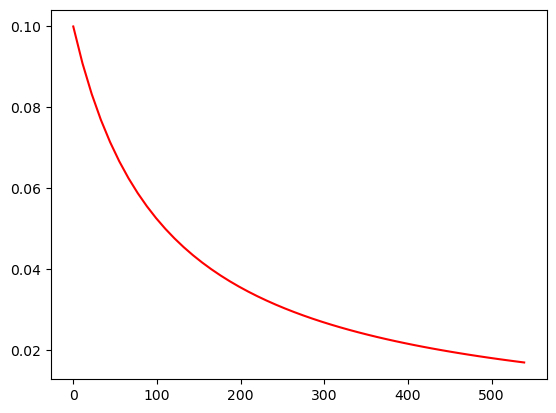

In [ ]:
plt.plot(epochs_iteration, lr_list, label='lr_0 = 1', c='red')
plt.plot(epochs_iteration, lambda_lr, label='lr=0.1', c='blue')
plt.legend()

In [ ]:
lambda_lr 

### impostando l'ottimizzatore del modello come Adam:

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import requests

file_dati = Path.cwd() / 'ionosphere.data'
if not file_dati.exists():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'

    # Scaricare il file .data


    # Scaricare il file .data
    response = requests.get(url)
    data = response.text

    # Salvare il contenuto del file .data in un file locale
    with open('ionosphere.data', 'w') as file:
        file.write(data)

# Leggere il file .data con pandas
column_names = [f'Attribute{i}' for i in range(1, 35)] + ['Class']
dataframe = pd.read_csv('ionosphere.data', header=None, names=column_names)

# Salvare il DataFrame in un file CSV
dataframe.to_csv('ionosphere.csv', index=False)

# load dataset, split into input (X) and output (y) variables

dataset = dataframe.values
X = dataset[:,0:34].astype(float)
y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

# convert into PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# train-test split for evaluation of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# create model
model = nn.Sequential(
    nn.Linear(34, 34),
    nn.ReLU(),
    nn.Linear(34, 1),
    nn.Sigmoid()
)
#Prepare list of values to track off
loss_list, lr_list, epoch_loss = [], [], []

# define the lambda funcrion for the lr lr=lr_0/(alpha + beta*epoch)
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
        
# Train the model
n_epochs = 50
batch_size = 24
batch_start = torch.arange(0, len(X_train), batch_size)
lr = 0.1
count = 0
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)
model.train()
for epoch in range(n_epochs):
    
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss_list.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        before_lr = optimizer.param_groups[0]["lr"]    
        optimizer.step()
        after_lr = optimizer.param_groups[0]["lr"]
        
        print("Epoch %d: ADAM lr %.4f -> %.4f" % (epoch, before_lr, after_lr)
        )
        count += 1
    before_lr = optimizer.param_groups[0]["lr"]
    lr_list.append(before_lr)
    
    #scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: ADAM lr %.4f -> %.4f" % (epoch, before_lr, after_lr))

# evaluate accuracy after training
model.eval()
y_pred = model(X_test)
acc = (y_pred.round() == y_test).float().mean()
acc = float(acc)
print("Model accuracy: %.2f%%" % (acc*100))

Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 0: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 1: ADAM lr 0.1000 -> 0.1000
Epoch 2: ADAM lr 0.1000 -> 0.1000
Epoch 2: ADAM lr 0.1000 -> 0.1000
Epoch 2: ADAM lr 0.1000 -> 0.1000
Epoch 2: ADAM lr 0.1000 -> 0.1000
Epoch 2: ADAM lr 0.1000 -> 0.1000
Epoch 2: ADAM 

In [ ]:
type(model)

torch.nn.modules.container.Sequential

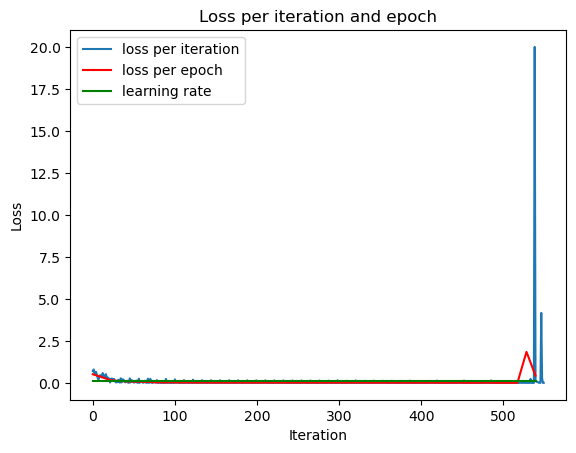

In [ ]:
iterations = [i for i in range(len(loss_list))]
epoch_loss = [sum(loss_list[i:i+len(batch_start)])/len(batch_start) for i in range(0, len(loss_list), len(batch_start))]
epochs_iteration = [i for i in range(0, len(loss_list), 11)]
plt.plot(iterations, loss_list, label='loss per iteration')
plt.plot(epochs_iteration, epoch_loss, label='loss per epoch', c='red')
plt.plot(epochs_iteration, lr_list, label='learning rate', c='green')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss per iteration and epoch')
plt.legend()
plt.savefig(Path.cwd().parent / 'Results' / 'SGD_lambda_lr_1.0_loss_per_iteration_and_epoch.png')


In [ ]:
optimizer.param_groups[0].keys()

dict_keys(['params', 'lr', 'betas', 'eps', 'weight_decay', 'amsgrad', 'maximize', 'foreach', 'capturable', 'differentiable', 'fused', 'initial_lr'])

 vedi FOREACH implementation nell'ottimizzazione

In [ ]:
for i in batch_start:
    #print(i)
    if i%240 == 0:
        print('done')

done
done


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Definizione del modello
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Creazione del modello
model = SimpleNN()

# Definizione dell'ottimizzatore Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dati di esempio
input = torch.randn(100, 10)
target = torch.randn(100, 1)

# Funzione di perdita
loss_fn = nn.MSELoss()
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)

# Ciclo di addestramento
for epoch in range(10):
    # Azzeramento dei gradienti
    optimizer.zero_grad()
    
    # Calcolo della perdita
    output = model(input)
    loss = loss_fn(output, target)
    
    # Backpropagation
    loss.backward()
    
    # Aggiornamento dei parametri
    optimizer.step()
    
    # Stampa del learning rate effettivo per ogni parametro
    print(f"Epoch {epoch+1}")
    for i, param_group in enumerate(optimizer.param_groups):
        print(f"  Param Group {i+1}:")
        for param in param_group['params']:
            state = optimizer.state[param]
            if 'step' in state and state['step'] > 0:
                bias_correction1 = 1 - optimizer.defaults['betas'][0] ** state['step']
                bias_correction2 = 1 - optimizer.defaults['betas'][1] ** state['step']
                adapted_lr = optimizer.defaults['lr'] * (bias_correction2 ** 0.5) / bias_correction1
                print(f"    Adapted LR: {adapted_lr}")
    print(f'epoca:{epoch+1}, loss: {loss.item()}, general lr : {optimizer.param_groups[0]['lr']}' )
    
    scheduler.step()

Epoch 1
  Param Group 1:
    Adapted LR: 0.00031622566166333854
    Adapted LR: 0.00031622566166333854
    Adapted LR: 0.00031622566166333854
    Adapted LR: 0.00031622566166333854
epoca:1, loss: 1.0251147747039795, general lr : 0.001
Epoch 2
  Param Group 1:
    Adapted LR: 0.0002353143790969625
    Adapted LR: 0.0002353143790969625
    Adapted LR: 0.0002353143790969625
    Adapted LR: 0.0002353143790969625
epoca:2, loss: 1.0230023860931396, general lr : 0.0009090909090909091
Epoch 3
  Param Group 1:
    Adapted LR: 0.0002020098763750866
    Adapted LR: 0.0002020098763750866
    Adapted LR: 0.0002020098763750866
    Adapted LR: 0.0002020098763750866
epoca:3, loss: 1.0211243629455566, general lr : 0.0008333333333333334
Epoch 4
  Param Group 1:
    Adapted LR: 0.00018376714433543384
    Adapted LR: 0.00018376714433543384
    Adapted LR: 0.00018376714433543384
    Adapted LR: 0.00018376714433543384
epoca:4, loss: 1.0194282531738281, general lr : 0.0007692307692307692
Epoch 5
  Param Grou